# Analyse de la stabilité et de la reproductibilité du G-score

## Objectif et question de l'étude

### Contexte

Cette étude vise à caractériser le comportement du **G-score** produit par le système NeoMundi à travers plusieurs campagnes de mesure, différents modèles et des répétitions successives d'une même condition.

L'objectif est d'évaluer dans quelle mesure le G-score présente des propriétés de **stabilité, de reproductibilité et de robustesse**, et d'identifier les éventuelles variations liées aux prompts, aux modèles ou aux différentes campagnes.

### Question principale

> **Dans quelle mesure le G-score constitue-t-il un signal stable et reproductible lorsque l'on fait varier les répétitions, les prompts, les modèles et les campagnes de mesure ?**

L'analyse cherche notamment à déterminer :

- si les répétitions d'une même condition produisent des valeurs de G-score similaires ;
- quelle part de la variabilité est liée aux différences entre prompts et quelle part est liée aux répétitions d'un même prompt ;
- si le niveau et la variabilité du G-score diffèrent selon les modèles ;
- si le G-score reste stable entre les différentes campagnes ;
- si certaines campagnes présentent une rupture ou une variation particulière ;
- si les variations observées peuvent être associées aux conditions d'exécution, notamment à la latence, au nombre de tokens ou aux erreurs ;
- si les conclusions restent robustes lorsque l'on prend en compte les observations atypiques.

### Hypothèses et axes d'analyse

L'analyse est organisée autour de plusieurs dimensions complémentaires :

1. **Répétabilité** : stabilité du G-score entre les répétitions d'une même condition.
2. **Variabilité inter-prompt** : différences de niveau de G-score entre les prompts.
3. **Variabilité intra-prompt** : dispersion du G-score entre les répétitions d'un même prompt.
4. **Effet modèle** : différences de niveau et de variabilité entre les modèles.
5. **Stabilité entre campagnes** : comparaison des campagnes B1 à B5, puis B7 et B8.
6. **Conditions d'exécution** : étude de la relation éventuelle entre G-score, latence, nombre de tokens et erreurs.
7. **Robustesse** : vérification de la stabilité des conclusions en présence d'observations atypiques.
8. **Modélisation statistique** : utilisation de modèles mixtes afin de tenir compte de la structure répétée des observations.

### Principe d'interprétation

L'objectif n'est pas de conclure uniquement sur la significativité statistique des différences observées, mais également d'évaluer :

- leur **amplitude** ;
- leur **importance pratique** ;
- leur **robustesse selon les méthodes utilisées** ;
- leur **cohérence entre les modèles et les campagnes**.

Les résultats seront donc interprétés conjointement à partir des analyses descriptives, des mesures de variabilité, des indicateurs de reproductibilité, des tests statistiques, des tailles d'effet et des modèles mixtes.

### Organisation de l'étude

Le notebook est structuré selon les étapes suivantes :

1. Construction du dataset ;
2. Contrôle qualité des données ;
3. Description du dataset ;
4. Description du G-score ;
5. Répétabilité et variabilité ;
6. Effet des modèles ;
7. Stabilité entre les campagnes ;
8. Modèles mixtes ;
9. Conditions d'exécution ;
10. Analyses de robustesse ;
11. Synthèse des résultats ;
12. Limites et perspectives.




## Convention utilisée dans l'analyse

Pour l'analyse temporelle, les campagnes **B1 à B4** constituent la période de référence. La campagne **B5** est étudiée spécifiquement en raison de la rupture observée du G-score. Les campagnes **B7 et B8** permettent ensuite d'étudier l'évolution du signal après cette rupture.

Les analyses ne cherchent pas à attribuer automatiquement une cause à une variation observée. Lorsqu'une association avec une variable technique est étudiée, elle est interprétée comme une **association statistique** et non comme une relation causale, sauf élément permettant de l'établir.

Les conclusions finales reposent sur la convergence des différentes analyses plutôt que sur un indicateur statistique unique.

## Imports

In [1]:

# 1.1 — Imports

import zipfile
import shutil
import os
import glob
import re
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import scikit_posthocs as spc
import pingouin as pg

from statsmodels.formula.api import mixedlm

sns.set_style("whitegrid")

warnings.filterwarnings("ignore")

print("Imports effectués avec succès.")

Imports effectués avec succès.


## 1.2. Paramètres de l'étude

Le dataset étudié comprend sept campagnes : B1, B2, B3, B4, B5, B7 et B8.

Chaque campagne comprend 12 modèles, soit 84 combinaisons baromètre × modèle. Chaque combinaison est associée à 400 observations.

Le nombre théorique total d'observations est donc de 33 600.

## Paramètres

In [2]:
os.makedirs("data", exist_ok=True)

zip_principal = "5 Baromètres pour Fatima.zip"

with zipfile.ZipFile(zip_principal, "r") as zip_ref:
    zip_ref.extractall("data")

print("Archive principale décompressée.")

Archive principale décompressée.


In [3]:
dossier_parent = "data/5 Baromètres pour Fatima"

if os.path.exists(dossier_parent):
    for nom in os.listdir(dossier_parent):
        source = os.path.join(dossier_parent, nom)
        destination = os.path.join("data", nom)

        if os.path.exists(destination):
            shutil.rmtree(destination)

        shutil.move(source, destination)

    shutil.rmtree(dossier_parent)

print("Contenu final de data :")
print(sorted(os.listdir("data")))

Contenu final de data :
['baromètre1', 'baromètre2', 'baromètre3', 'baromètre4', 'baromètre5']


## Extraction B7 

In [4]:
with zipfile.ZipFile("results_baromètre_7.zip", "r") as zip_ref:
    zip_ref.extractall("data/temp7")

if os.path.exists("data/baromètre7"):
    shutil.rmtree("data/baromètre7")

shutil.move("data/temp7/results","data/baromètre7")

shutil.rmtree("data/temp7")

print("Baromètre 7 préparé.")

Baromètre 7 préparé.


##Extraction B8

In [5]:
with zipfile.ZipFile("results_baromètre_8.zip", "r") as zip_ref:
    zip_ref.extractall("data/temp8")

if os.path.exists("data/baromètre8"):
    shutil.rmtree("data/baromètre8")

shutil.move("data/temp8/results","data/baromètre8")
shutil.rmtree("data/temp8")

print("Baromètre 8 préparé.")

Baromètre 8 préparé.


In [6]:
#Vérification du dossier de travail
print("Contenu final de data :")
print(sorted(os.listdir("data")))

Contenu final de data :
['baromètre1', 'baromètre2', 'baromètre3', 'baromètre4', 'baromètre5', 'baromètre7', 'baromètre8']


#### Inventaire des fichiers de résultats

Les fichiers de résultats présents dans les sept campagnes sont recensés afin de vérifier la couverture des modèles et d'identifier les éventuels doublons avant la sélection des fichiers utilisés pour construire le dataset canonique.

In [7]:
fichiers = glob.glob(
    os.path.join(
        "data",
        "**",
        "*_results.csv"
    ),
    recursive=True
)

inventaire = []

for fichier in fichiers:
    barometre = os.path.basename(
        os.path.dirname(fichier)
    )

    nom_fichier = os.path.basename(fichier)

    modele = re.split(
        r'_weekly_|_barometre_\d+_',
        nom_fichier
    )[0]

    inventaire.append({
        "baromètre": barometre,
        "modèle": modele,
        "fichier": fichier
    })

df_inventaire = pd.DataFrame(inventaire)

print("Nombre total de fichiers :", len(df_inventaire))

print("\nNombre de fichiers par baromètre :")
print(
    df_inventaire["baromètre"]
    .value_counts()
    .sort_index()
)

Nombre total de fichiers : 112

Nombre de fichiers par baromètre :
baromètre
baromètre1    12
baromètre2    12
baromètre3    12
baromètre4    12
baromètre5    40
baromètre7    12
baromètre8    12
Name: count, dtype: int64


In [8]:
df_inventaire.head(5)

,baromètre,modèle,fichier
0,baromètre1,anthropic_claude-sonnet-4-5-20250929,data\baromètre1\anthropic_claude-sonnet-4-5-20...
1,baromètre1,cohere_command-a-03-2025,data\baromètre1\cohere_command-a-03-2025_weekl...
2,baromètre1,deepseek_deepseek-chat,data\baromètre1\deepseek_deepseek-chat_weekly_...
3,baromètre1,google_gemini-2.5-flash,data\baromètre1\google_gemini-2.5-flash_weekly...
4,baromètre1,infomaniak_mistralai_Mistral-Small-4-119B-2603,data\baromètre1\infomaniak_mistralai_Mistral-S...


#### Vérification des combinaisons baromètre × modèle

Chaque baromètre doit contenir les mêmes 12 modèles. On vérifie ici que les 84 combinaisons attendues sont bien présentes avant de procéder à la sélection des fichiers.

In [9]:
combinaisons = (
    df_inventaire[
        ["baromètre", "modèle"]
    ]
    .drop_duplicates()
    .sort_values(
        ["baromètre", "modèle"]
    )
)

print("Nombre de combinaisons baromètre × modèle :",len(combinaisons))

print("\nNombre de modèles par baromètre :")

print(
    combinaisons
    .groupby("baromètre")["modèle"]
    .nunique()
    .sort_index()
)

Nombre de combinaisons baromètre × modèle : 84

Nombre de modèles par baromètre :
baromètre
baromètre1    12
baromètre2    12
baromètre3    12
baromètre4    12
baromètre5    12
baromètre7    12
baromètre8    12
Name: modèle, dtype: int64


#### Identification des fichiers multiples

Plusieurs fichiers peuvent correspondre à une même combinaison baromètre × modèle. le but c'est de répondre à la question de est-ce qu'on a bien 12 modèles pour chacun des 7 baromètres ?

In [10]:
doublons = (
    df_inventaire
    .groupby(
        ["baromètre", "modèle"]
    )
    .size()
    .reset_index(
        name="nombre_fichiers"
    )
)

doublons = doublons[
    doublons["nombre_fichiers"] > 1
]

if doublons.empty:
    print("Aucun fichier multiple détecté.")
else:
    print("Combinaisons avec plusieurs fichiers :")
    display(doublons)

Combinaisons avec plusieurs fichiers :


,baromètre,modèle,nombre_fichiers
48,baromètre5,anthropic_claude-sonnet-4-5-20250929,3
49,baromètre5,cohere_command-a-03-2025,7
50,baromètre5,deepseek_deepseek-chat,3
51,baromètre5,google_gemini-2.5-flash,3
52,baromètre5,infomaniak_mistralai_Mistral-Small-4-119B-2603,3
53,baromètre5,infomaniak_swiss-ai_Apertus-70B-Instruct-2509,3
54,baromètre5,mistral_mistral-large-latest,3
55,baromètre5,openai_gpt-4o-2024-11-20,3
56,baromètre5,perplexity_sonar,3
57,baromètre5,qwen_qwen-plus,3


#### Sélection du fichier de référence

Certaines combinaisons baromètre × modèle disposent de plusieurs fichiers de résultats, principalement pour la campagne B5.

Pour construire un dataset canonique contenant une seule version par combinaison baromètre × modèle, un fichier de référence est sélectionné selon deux critères successifs :

1. le nombre d'erreurs d'exécution le plus faible ;
2. en cas d'égalité, le nombre d'observations le plus élevé.

Cette règle permet de privilégier les fichiers les plus complets et les moins affectés par les erreurs.

In [11]:
selections = []

for (barometre, modele), groupe in df_inventaire.groupby(
    ["baromètre", "modèle"]
):

    candidats = []

    for _, ligne in groupe.iterrows():

        df = pd.read_csv(ligne["fichier"])

        nb_erreurs = df["error"].notna().sum()
        nb_lignes = len(df)

        candidats.append({
            "baromètre": barometre,
            "modèle": modele,
            "fichier": ligne["fichier"],
            "nombre_erreurs": nb_erreurs,
            "nombre_lignes": nb_lignes
        })

    candidats = pd.DataFrame(candidats)
    meilleur = (candidats.sort_values( ["nombre_erreurs", "nombre_lignes"],ascending=[True, False]).iloc[0])#inden

    selections.append(meilleur)

df_selection = pd.DataFrame(selections)
print("Nombre de fichiers sélectionnés :",len(df_selection))

Nombre de fichiers sélectionnés : 84


In [12]:
df_selection.columns

Index(['baromètre', 'modèle', 'fichier', 'nombre_erreurs', 'nombre_lignes'], dtype='str')

In [13]:
df_selection.to_csv('journal_selection.csv', index=False)
print("Journal de sélection sauvegardé dans journal_selection.csv")

Journal de sélection sauvegardé dans journal_selection.csv


#### Construction du dataset canonique

Les fichiers de référence sélectionnés pour chaque combinaison baromètre × modèle sont fusionnés afin de construire un tableau unique. Les variables nécessaires aux analyses sont conservées et les informations relatives au baromètre et au modèle sont ajoutées à chaque observation.

In [14]:
# Fusion de tous les fichiers sélectionnés en un seul tableau
# en ajoutant une colonne baromètre et une colonne modèle sur chaque ligne, pour pouvoir ensuite comparer
# et filtrer facilement selon ces deux axes

colonnes_utiles = [
    'prompt_id', 'prompt_family', 'repetition_index', 'decision',
    'g_score', 'g_final', 'v_score', 'delta_g',
    'stability_score', 'coherence_score', 'semantic_risk',
    'factual_hallucination_score', 'semantic_instability_score',
    'information_density', 'latency_ms', 'token_count', 'error']

tableaux = []

for _, ligne in df_selection.iterrows():
    df_fichier = pd.read_csv(ligne['fichier'], usecols=colonnes_utiles)
    df_fichier['baromètre'] = ligne['baromètre']
    df_fichier['modèle'] = ligne['modèle']
    tableaux.append(df_fichier)

df_canonique = pd.concat(tableaux, ignore_index=True)

print(f"Dataset canonique construit : {df_canonique.shape[0]} lignes, {df_canonique.shape[1]} colonnes")
print()
print("Nombre de lignes attendu : 84 x 400 =", 84 * 400)
print("Nombre de lignes obtenu  :", len(df_canonique))
print()
print("Répartition par baromètre :")
print(df_canonique['baromètre'].value_counts())

df_canonique.to_csv('dataset_canonique.csv', index=False)

print()
print("Dataset canonique sauvegardé dans dataset_canonique.csv")

Dataset canonique construit : 33600 lignes, 19 colonnes

Nombre de lignes attendu : 84 x 400 = 33600
Nombre de lignes obtenu  : 33600

Répartition par baromètre :
baromètre
baromètre1    4800
baromètre2    4800
baromètre3    4800
baromètre4    4800
baromètre5    4800
baromètre7    4800
baromètre8    4800
Name: count, dtype: int64

Dataset canonique sauvegardé dans dataset_canonique.csv


#### 2) Contrôle qualité du dataset canonique
Avant les analyses statistiques, la structure et la qualité du dataset canonique sont vérifiées.
Les contrôles portent sur :

- les dimensions du dataset ;
- la couverture des modèles et des baromètres ;
- le nombre dobservations par combinaison modèle × baromètre ;
- le nombre de répétitions par prompt ;
- les doublons expérimentaux ;
- les doublons exacts ;
- les valeurs manquantes du G-score ;
- les valeurs du G-score hors de l'intervalle attendu [0, 1] ;
- les erreurs techniques ;
- la cohérence entre les erreurs et les valeurs manquantes du G-score ;
- la distribution de la variable de décision.

In [15]:
#df_canonique.head()

##### 2.1 Dimension du dataset 

In [16]:
print("Dimensions du dataset est ")

n_lignes, n_colonnes = df_canonique.shape

print("Nombre de lignes :", n_lignes)
print("Nombre de colonnes :", n_colonnes)

print("Nombre de lignes attendu :", 84 * 400)

if n_lignes == 84 * 400:
    print("Nombre de lignes conforme.")
else:
    print("Nombre de lignes différent de l'attendu.")

Dimensions du dataset est 
Nombre de lignes : 33600
Nombre de colonnes : 19
Nombre de lignes attendu : 33600
Nombre de lignes conforme.


##### 2.2 Couverture du plan expérimental
Vérification du nombre de modèles, de baromètres et de la répartition des observations par baromètre.

In [17]:
print("Couverture du plan expérimental")

n_modeles = df_canonique["modèle"].nunique()
n_barometres = df_canonique["baromètre"].nunique()

print("Nombre de modèles :", n_modeles)
print("Nombre de baromètres :", n_barometres)

print("\nNombre d'observations par baromètre :")

print(df_canonique["baromètre"].value_counts().sort_index())

Couverture du plan expérimental
Nombre de modèles : 12
Nombre de baromètres : 7

Nombre d'observations par baromètre :
baromètre
baromètre1    4800
baromètre2    4800
baromètre3    4800
baromètre4    4800
baromètre5    4800
baromètre7    4800
baromètre8    4800
Name: count, dtype: int64


#####  2.3 Nombre d'observations par combinaison modèle × baromètre

Chaque combinaison modèle × baromètre doit contenir 400 observations.

In [18]:
print("Observations par modèle × baromètre")

effectifs = (df_canonique.groupby(["modèle", "baromètre"]).size())
print("Nombre de combinaisons :", len(effectifs))
print("Minimum :", effectifs.min())
print("Maximum :", effectifs.max())

combinaisons_non_400 = effectifs[effectifs != 400]

if len(combinaisons_non_400) == 0:
    print("Toutes les combinaisons contiennent 400 observations.")
else:
    print("Combinaisons différentes de 400 observations :")
    print(combinaisons_non_400)

Observations par modèle × baromètre
Nombre de combinaisons : 84
Minimum : 400
Maximum : 400
Toutes les combinaisons contiennent 400 observations.


##### 2.4 Nombre de répétitions par prompt

Chaque prompt doit disposer de 100 répétitions pour chaque combinaison modèle × baromètre.

In [19]:
print("Répétitions par modèle × baromètre × prompt")

repetitions = (df_canonique.groupby(["modèle", "baromètre", "prompt_id"])["repetition_index"].nunique())

print("Nombre de conditions :", len(repetitions))
print("Minimum :", repetitions.min())#
print("Maximum :", repetitions.max())

conditions_non_100 = repetitions[repetitions != 100]

if len(conditions_non_100) == 0:
    print("Chaque prompt possède 100 répétitions.")
else:
    print("Conditions différentes de 100 répétitions :")
    print(conditions_non_100)

Répétitions par modèle × baromètre × prompt
Nombre de conditions : 336
Minimum : 100
Maximum : 100
Chaque prompt possède 100 répétitions.


##### 2.5 Vérification des doublons expérimentaux
l'idée vient du fait q'une combinaison : modèle × baromètre × prompt × répétition devrait normalement correspondre à une exécution dans le cadre de cette étude.


In [20]:
cles_experimentales = ["modèle","baromètre","prompt_id","repetition_index"]

nb_doublons_experimentaux = (df_canonique.duplicated(subset=cles_experimentales).sum())

print("Doublons modèle × baromètre × prompt × répétition :",nb_doublons_experimentaux)

if nb_doublons_experimentaux == 0:
    print("Aucun doublon expérimental.")
else:
    print("Des doublons expérimentaux sont présents.")

Doublons modèle × baromètre × prompt × répétition : 0
Aucun doublon expérimental.


##### 2.6 Vérification des doublons exacts

la différence c'estt qu'on voulait vérifier si certaines lignes du dataset sont strictement identiques sur l'ensemble des variables.

In [21]:
nb_doublons_exacts = df_canonique.duplicated().sum()

print("Nombre de lignes strictement identiques :",nb_doublons_exacts
)

if nb_doublons_exacts == 0:
    print("Aucun doublon exact")
else:
    print("Des doublons exacts sont présents")

Nombre de lignes strictement identiques : 0
Aucun doublon exact


##### 2;7 valeurs manquantes


In [22]:
print(" Valeurs manquantes")

manquants = df_canonique.isna().sum()
manquants = manquants[manquants > 0]

if manquants.empty:
    print(" Aucune valeur manquante.")
else:
    print(manquants)

 Valeurs manquantes
token_count                      199
latency_ms                       199
g_score                          199
g_final                          199
v_score                          315
delta_g                          205
stability_score                  199
coherence_score                  199
semantic_risk                    199
factual_hallucination_score      199
semantic_instability_score       199
information_density              199
error                          33401
dtype: int64


##### 2.8 Contrôle du G-score


In [23]:
print("Contrôle du G-score")

nb_g_manquants = df_canonique["g_score"].isna().sum()

print("G-score manquants :", nb_g_manquants)

g_score_valides = df_canonique["g_score"].dropna()

print("Minimum :", g_score_valides.min())
print("Maximum :", g_score_valides.max())

nb_g_hors_bornes = ((g_score_valides < 0) |(g_score_valides > 1)).sum()

print("G-score hors de [0, 1] :", nb_g_hors_bornes)

if nb_g_hors_bornes == 0:
    print(" Tous les G-scores sont dans [0, 1]")
else:
    print("Certains G-scores sont hors de [0, 1]")

Contrôle du G-score
G-score manquants : 199
Minimum : 0.33734
Maximum : 0.6
G-score hors de [0, 1] : 0
 Tous les G-scores sont dans [0, 1]


##### 2.9  Erreurs techniques

On va essayer d'identification le nombre et de la proportion de lignes présentant une erreur technique, ainsi que leur répartition par baromètre.

In [24]:
print("Erreurs techniques")

nb_erreurs = df_canonique["error"].notna().sum()

proportion_erreurs = nb_erreurs / len(df_canonique)

print("Nombre de lignes en erreur :", nb_erreurs)
print("Proportion d'erreurs :", f"{proportion_erreurs:.3%}")

print("\nRépartition des erreurs par baromètre :")

erreurs_par_barometre = (df_canonique[df_canonique["error"].notna()]["baromètre"].value_counts().sort_index())
print(erreurs_par_barometre)

Erreurs techniques
Nombre de lignes en erreur : 199
Proportion d'erreurs : 0.592%

Répartition des erreurs par baromètre :
baromètre
baromètre1     25
baromètre2     20
baromètre3      1
baromètre4     42
baromètre5      2
baromètre7      1
baromètre8    108
Name: count, dtype: int64


##### 2.10 Cohérence entre les erreurs et le G-score

On va vérifie si les lignes présentant une erreur technique correspondent aux observations pour lesquelles le G-score est manquant.

In [25]:
print("Cohérence erreurs / G-score")

lignes_en_erreur = df_canonique["error"].notna()

g_manquant_dans_erreurs = (df_canonique.loc[lignes_en_erreur,"g_score"].isna().sum())

print(
"Erreurs avec G-score manquant :", g_manquant_dans_erreurs, "/",nb_erreurs )

if g_manquant_dans_erreurs == nb_erreurs:
    print("Toutes les lignes en erreur ont un G-score manquant.")
else:
    print("certaines lignes en erreur possèdent un G-score.")

Cohérence erreurs / G-score
Erreurs avec G-score manquant : 199 / 199
Toutes les lignes en erreur ont un G-score manquant.


### 2.11 Distribution de la variable de décision

Vérification des modalités observées pour la variable de décision utilisée dans l'étude.

In [26]:
print(" Distribution de la variable decision")
print(df_canonique["decision"].value_counts(dropna=False))

 Distribution de la variable decision
decision
ALLOW    32971
FLAG       430
ERROR      199
Name: count, dtype: int64


#### Synthèse des résultats de sélection

**1.** Sur les 84 combinaisons baromètre × modèle, 12 ont nécessité plusieurs tentatives. Elles concernent toutes le **baromètre 5**, avec les 12 modèles, et entre 3 et 7 tentatives selon le modèle. Pour les autres baromètres (1 à 4, 7 et 8), une seule tentative était disponible pour chaque modèle.

**2.** Le baromètre 5 se distingue donc clairement des autres campagnes par le nombre de tentatives nécessaires. Les problèmes rencontrés semblent ainsi concentrés sur cette campagne. Il faut toutefois rester prudent avant de parler d'un problème spécifique au baromètre 5, car les autres campagnes ne disposent pas de plusieurs tentatives permettant de faire la même comparaison.

**3.** Lorsque plusieurs tentatives étaient disponibles, comme pour le baromètre 5, le fichier présentant le moins d'erreurs a été retenu, puis le nombre de lignes a été utilisé pour départager les fichiers en cas d'égalité. En revanche, lorsqu'une seule tentative était disponible, les erreurs présentes dans celle-ci ne pouvaient pas être remplacées par une autre exécution. C'est notamment le cas de **'xai_grok-4' au baromètre 8**, avec 108 erreurs sur 400 observations (27 %), alors que les 11 autres modèles ne présentent pas d'erreur à ce baromètre. On observe également **25 erreurs pour 'cohere' au baromètre 1**.

### Limite à retenir

La sélection du meilleur run n'a donc pu être appliquée que pour le **baromètre 5**, où plusieurs tentatives étaient disponibles. Les erreurs présentes dans les autres baromètres ont été conservées dans le dataset, puisqu'il n'existait pas de seconde tentative permettant de les remplacer.

Au total, **199 lignes sur 33 600 (0,592 %)** présentent une erreur. Ces lignes ont un `g_score` manquant et ne sont donc pas utilisées dans les calculs qui portent sur cette variable.

#### ÉTUDE COMPLÈTE — Reproductibilité et invariance du score G
#### Structure en plusieurs locs, selon le plan validé


In [27]:
# On va commencer notre étude par la décomposition des baros en 3 groupes :
ordre_baro = ['baromètre1', 'baromètre2', 'baromètre3', 'baromètre4', 'baromètre5', 'baromètre7', 'baromètre8']
baros_reference = ['baromètre1', 'baromètre2', 'baromètre3', 'baromètre4']
barometre_variation = ['baromètre5']
baros_suivi = ['baromètre7', 'baromètre8']

#### BLOC A — Variabilité temporelle

L'objectif de cette partie est d'étudier l'évolution du G-score au cours des différentes campagnes.

Les baromètres sont considérés selon les trois groupes définis pour l'étude :
- Baromètres de référence : B1 à B4 ;
- Baromètre de variation : B5 ;
- Baromètres de suivi : B7 et B8.

On cherche notamment à déterminer si le niveau du G-score reste globalement stable sur les campagnes de référence, si une variation particulière apparaît en B5 et si cette variation se retrouve ou non lors des campagnes de suivi.

#### A1. Distribution du G-score selon le baromètre

Cette première visualisation permet de comparer la distribution du G-score entre les différentes campagnes et de repérer d'éventuelles variations de niveau ou de dispersion.

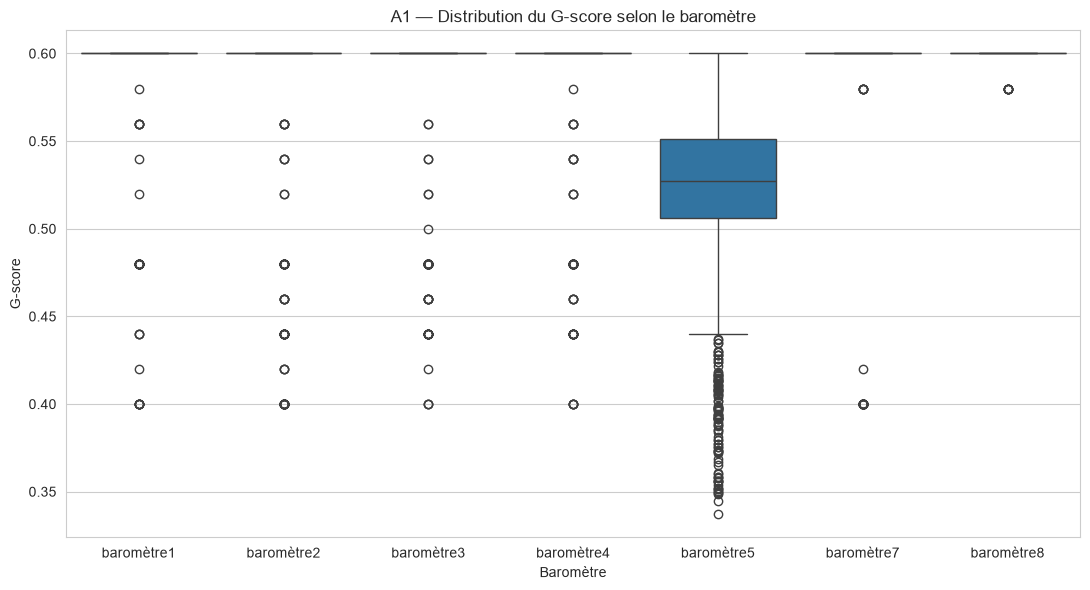

In [28]:
stats_baro = (
    df_canonique
    .groupby("baromètre")["g_score"]
    .agg(
        n="count",
        moyenne="mean",
        mediane="median",
        ecart_type="std"
    ).reindex(ordre_baro))

plt.figure(figsize=(11, 6))

sns.boxplot(data=df_canonique,x="baromètre",y="g_score",order=ordre_baro)
plt.xlabel("Baromètre")
plt.ylabel("G-score")
plt.title("A1 — Distribution du G-score selon le baromètre")

plt.tight_layout()
plt.savefig("A1_distribution_g_score_barometre.png", dpi=150)
plt.show()

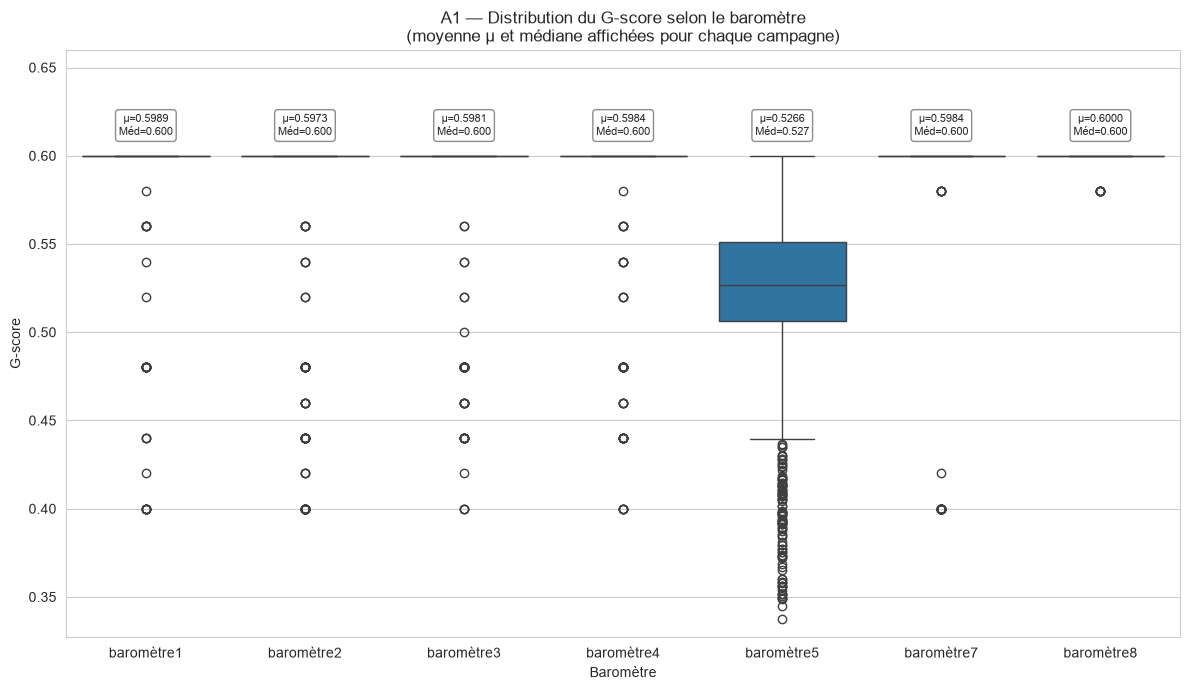

In [29]:
# A1 — Distribution du G-score selon le baromètre (version annotée)

stats_baro = (
    df_canonique
    .groupby("baromètre")["g_score"]
    .agg(
        n="count",
        moyenne="mean",
        mediane="median",
        ecart_type="std"
    ).reindex(ordre_baro))

fig, ax = plt.subplots(figsize=(12, 7))

sns.boxplot(data=df_canonique, x="baromètre", y="g_score", order=ordre_baro, ax=ax)

# Annotation : moyenne et médiane, affichées au-dessus de chaque boîte
y_max_plot = df_canonique['g_score'].max()
for i, baro in enumerate(ordre_baro):
    moyenne = stats_baro.loc[baro, 'moyenne']
    mediane = stats_baro.loc[baro, 'mediane']
    texte = f"μ={moyenne:.4f}\nMéd={mediane:.3f}"
    ax.text(
        i, y_max_plot + 0.01, texte,
        ha='center', va='bottom', fontsize=8,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.9)
    )

ax.set_ylim(df_canonique['g_score'].min() - 0.01, y_max_plot + 0.06)
ax.set_xlabel("Baromètre")
ax.set_ylabel("G-score")
ax.set_title("A1 — Distribution du G-score selon le baromètre\n(moyenne μ et médiane affichées pour chaque campagne)")

plt.tight_layout()
plt.savefig("A1_distribution_g_score_barometre.png", dpi=150, bbox_inches='tight')
plt.show()

#### A2. Niveau moyen du G-score selon le modèle et le baromètre

Afin d'identifier les différences de comportement entre modèles et campagnes, les moyennes du G-score sont comparées pour chaque combinaison modèle × baromètre.

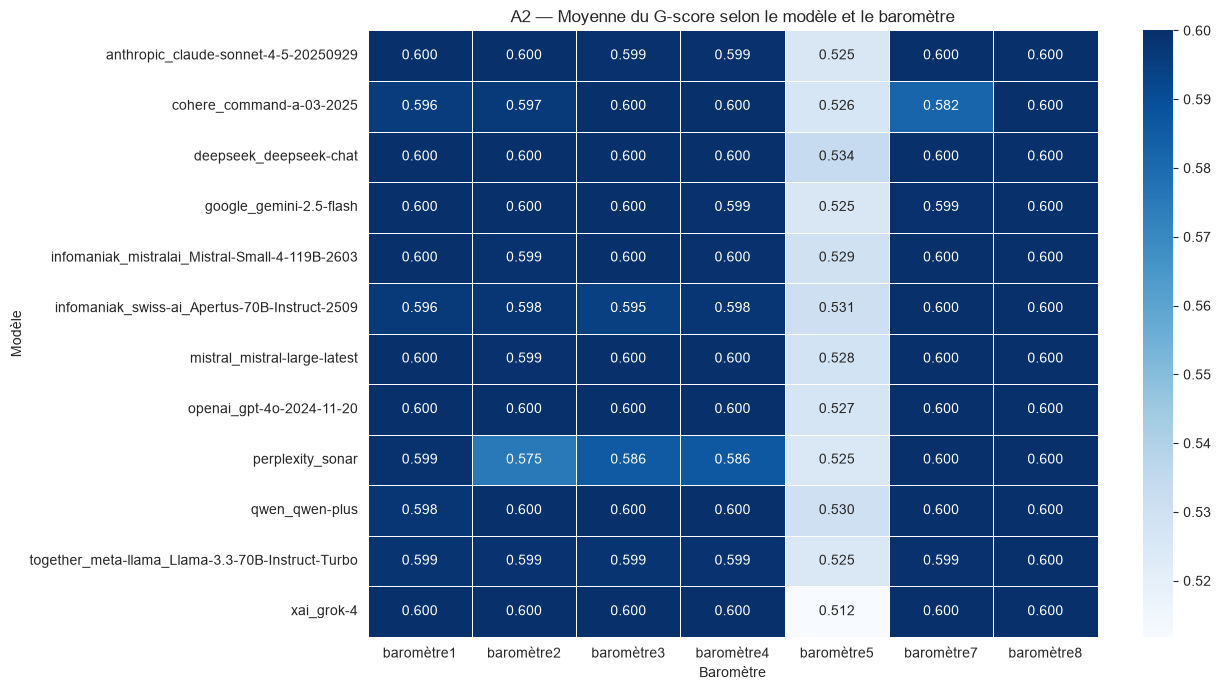

In [30]:
moyennes_modele_baro = (df_canonique.groupby(["modèle", "baromètre"])["g_score"].mean().unstack().reindex(columns=ordre_baro))
plt.figure(figsize=(13, 7))
sns.heatmap(
    moyennes_modele_baro,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    linewidths=0.5
)

plt.xlabel("Baromètre")
plt.ylabel("Modèle")
plt.title("A2 — Moyenne du G-score selon le modèle et le baromètre")

plt.tight_layout()
plt.savefig("A2_heatmap_g_score_modele_barometre.png", dpi=150)
plt.show()


#### A3. Évolution du G-score au cours des campagnes

La moyenne du G-score est comparée entre les campagnes afin de visualiser l'évolution générale entre la période de référence, B5 et les campagnes de suivi B7-B8.

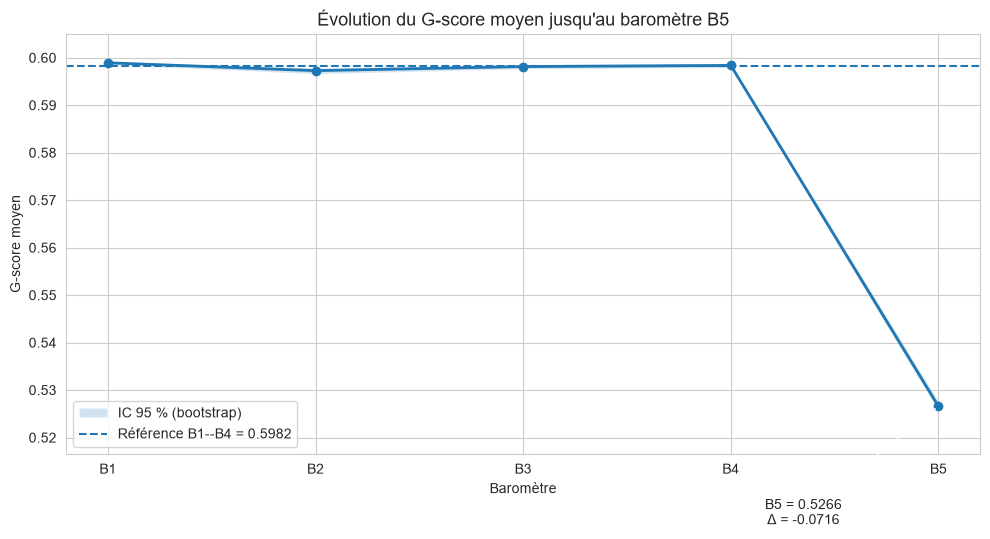

In [31]:
# A3 — Évolution du G-score moyen jusqu'à B5
# avec IC 95 % bootstrap
np.random.seed(42)

ordre_baro_b5 = [
    "baromètre1",
    "baromètre2",
    "baromètre3",
    "baromètre4",
    "baromètre5"
]

def ic_bootstrap(serie, n_iterations=1000, niveau=0.95):
    valeurs = serie.dropna().values

    moyennes = [
        np.random.choice(
            valeurs,
            size=len(valeurs),
            replace=True
        ).mean()
        for _ in range(n_iterations)
    ]

    alpha = (1 - niveau) / 2

    return (valeurs.mean(),np.percentile(moyennes, alpha * 100),np.percentile(moyennes, (1 - alpha) * 100))

# Moyenne + IC 95 %
resultats = []

for baro in ordre_baro_b5:

    serie = df_canonique[
        df_canonique["baromètre"] == baro]["g_score"]

    moy, bas, haut = ic_bootstrap(serie)

    resultats.append({
        "baromètre": baro,
        "moyenne": moy,
        "ic_bas": bas,
        "ic_haut": haut,
        "n": serie.notna().sum()
    })

df_resultats = pd.DataFrame(resultats)

# Moyenne de référence B1-B4
moyenne_reference = df_resultats.iloc[:4]["moyenne"].mean()

# B5
moyenne_b5 = df_resultats.loc[
    df_resultats["baromètre"] == "baromètre5",
    "moyenne"].iloc[0]

difference_b5 = moyenne_b5 - moyenne_reference


# Figure
fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(ordre_baro_b5))
moyennes = df_resultats["moyenne"].values
ic_bas = df_resultats["ic_bas"].values
ic_haut = df_resultats["ic_haut"].values

# Courbe
ax.plot(x,moyennes,marker="o",linewidth=2)

# IC 95 %
ax.fill_between(x,ic_bas,ic_haut,alpha=0.20,label="IC 95 % (bootstrap)")

# Niveau de référence
ax.axhline(
    moyenne_reference,
    linestyle="--",
    linewidth=1.5,
    label=f"Référence B1--B4 = {moyenne_reference:.4f}"
)

# Annotation uniquement sur B5
ax.annotate(
    f"B5 = {moyenne_b5:.4f}\n"
    f"$\\Delta$ = {difference_b5:.4f}",
    xy=(4, moyenne_b5),
    xytext=(3.35, moyenne_b5 - 0.025),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10,
    ha="center"
)

# Axes
ax.set_xticks(x)
ax.set_xticklabels(["B1", "B2", "B3", "B4", "B5"])

ax.set_xlabel("Baromètre")
ax.set_ylabel("G-score moyen")

ax.set_title(
    "Évolution du G-score moyen jusqu'au baromètre B5",fontsize=13)

# Limites pour mieux voir la rupture
ax.set_ylim(min(ic_bas.min() - 0.005, moyenne_b5 - 0.01),0.605)

ax.legend(loc="lower left")

plt.tight_layout()

plt.savefig(
    "A3_evolution_g_score_moyen_B1_B5.png",dpi=150, bbox_inches="tight"
)

plt.show()
plt.show()

### Taux de FLAG selon le baromètre
Question : le changement temporel observé sur le G s'accompagne-t-il d'une évolution du taux de FLAG ?
En particulier : le taux de FLAG remonte-t-il aux baromètres 7 et 8, comme au 5 ?

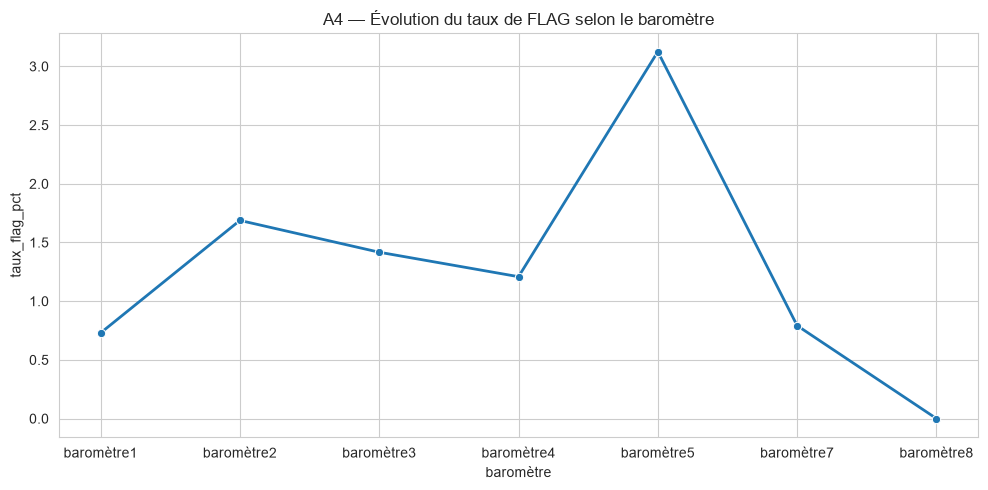

    baromètre  taux_flag_pct
0  baromètre1       0.729167
1  baromètre2       1.687500
2  baromètre3       1.416667
3  baromètre4       1.208333
4  baromètre5       3.125000
5  baromètre7       0.791667
6  baromètre8       0.000000


In [32]:
#graphe comme indicateur complémentaire!
taux_flag_baro = (df_canonique.groupby('baromètre')['decision'] 
                   .apply(lambda x: (x == 'FLAG').mean() * 100).reindex(ordre_baro).reset_index(name='taux_flag_pct'))
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=taux_flag_baro, x='baromètre', y='taux_flag_pct', marker='o', linewidth=2, ax=ax)
ax.set_title("A4 — Évolution du taux de FLAG selon le baromètre")
plt.tight_layout()
plt.savefig('A4_taux_flag_par_barometre.png', dpi=150)
plt.show()
print(taux_flag_baro)


#### A5. Statistiques descriptives du G-score par baromètre

Les principales statistiques descriptives sont présentées afin de compléter les visualisations précédentes.

In [33]:
# A5 — Statistiques descriptives du G-score par baromètre
stats_baro = (
    df_canonique.groupby('baromètre')['g_score']
    .agg(
        n='count',
        moyenne='mean',
        mediane='median',
        ecart_type='std',
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75)
    ).reindex(ordre_baro))

stats_baro['IQR'] = stats_baro['q3'] - stats_baro['q1']

print("Statistiques descriptives du G-score par baromètre ")
print(stats_baro.round(4))

Statistiques descriptives du G-score par baromètre 
               n  moyenne  mediane  ecart_type      q1      q3     IQR
baromètre                                                             
baromètre1  4775   0.5989    0.600      0.0125  0.6000  0.6000  0.0000
baromètre2  4780   0.5973    0.600      0.0212  0.6000  0.6000  0.0000
baromètre3  4799   0.5981    0.600      0.0158  0.6000  0.6000  0.0000
baromètre4  4758   0.5984    0.600      0.0148  0.6000  0.6000  0.0000
baromètre5  4798   0.5266    0.527      0.0339  0.5063  0.5512  0.0448
baromètre7  4799   0.5984    0.600      0.0177  0.6000  0.6000  0.0000
baromètre8  4692   0.6000    0.600      0.0008  0.6000  0.6000  0.0000


### BLOC B — Reproductibilité des répétitions

L'objectif est d'évaluer la stabilité du G-score lorsque la même expérience est répétée. L'analyse porte d'abord sur les baromètres de référence B1-B4.



#### B1 — Évolution du G-score

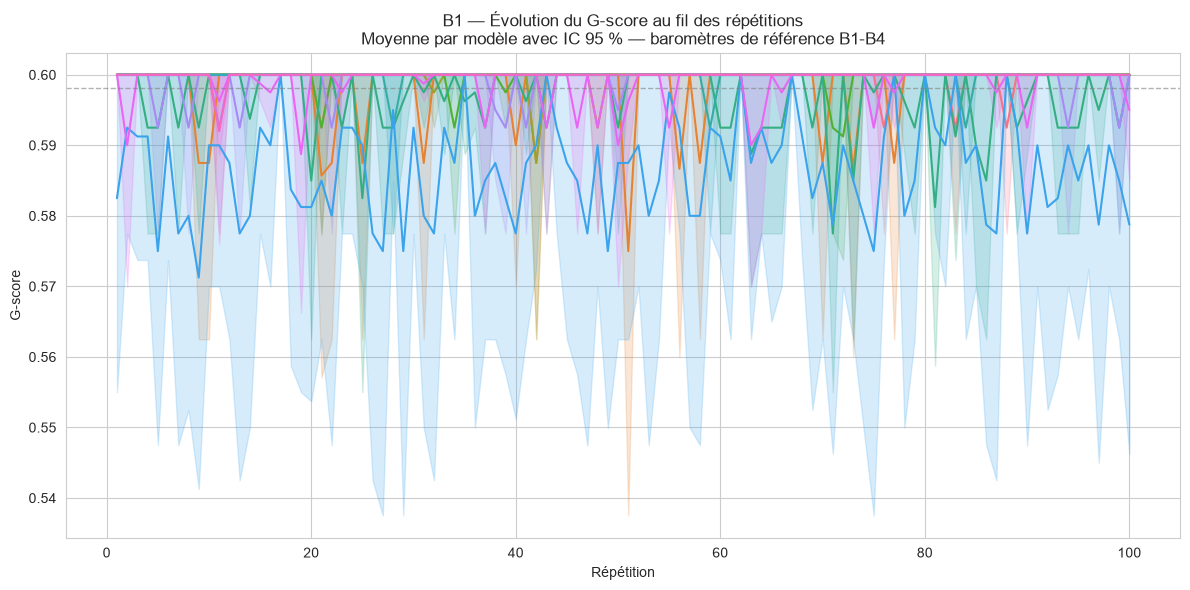

In [34]:
# B1 — Évolution du G-score au fil des répétitions
# Question : le G-score reste-t-il stable lorsque la même expérience est répétée 100 fois ?
# Analyse réalisée sur les baromètres de référence B1-B4,
# hors campagne opérationnellement atypique B5.

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=df_canonique[df_canonique['baromètre'].isin(baros_reference)],
             x='repetition_index', y='g_score', hue='modèle', estimator='mean', errorbar=('ci', 95), ax=ax, legend=False)

ax.set_title("B1 — Évolution du G-score au fil des répétitions\n" "Moyenne par modèle avec IC 95 % — baromètres de référence B1-B4")
ax.axhline(df_canonique[df_canonique['baromètre'].isin(baros_reference)]['g_score'].mean(),
           color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.set_xlabel("Répétition")
ax.set_ylabel("G-score")
plt.tight_layout()
plt.savefig('B1_g_score_par_repetition.png', dpi=150)
plt.show()


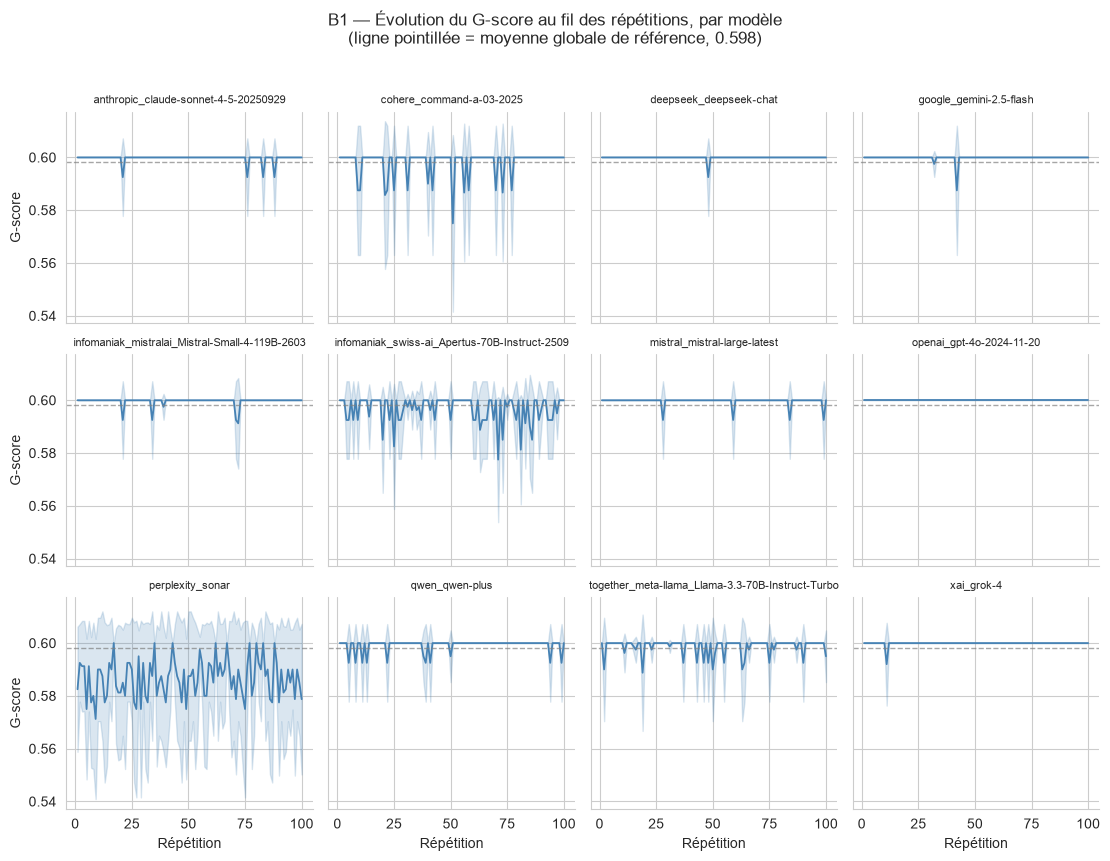

In [35]:
# B1 — Évolution du G-score au fil des répétitions (version facettée)
# Baromètres de référence B1-B4, un panneau par modèle

df_ref = df_canonique[df_canonique["baromètre"].isin(baros_reference)].copy()

summary = (
    df_ref
    .groupby(["modèle", "repetition_index"])["g_score"]
    .agg(["mean", "count", "std"])
    .reset_index()
)
summary["se"] = summary["std"] / summary["count"].pow(0.5)
summary["ci95"] = 1.96 * summary["se"]

global_mean = df_ref["g_score"].mean()

g = sns.FacetGrid(summary, col="modèle", col_wrap=4, height=2.8, sharey=True, sharex=True)

def plot_avec_ic(data, **kwargs):
    ax = plt.gca()
    data = data.sort_values("repetition_index")
    ax.plot(data["repetition_index"], data["mean"], linewidth=1.3, color="steelblue")
    ax.fill_between(
        data["repetition_index"],
        data["mean"] - data["ci95"],
        data["mean"] + data["ci95"],
        alpha=0.2, color="steelblue"
    )
    ax.axhline(global_mean, linestyle="--", linewidth=1, color="gray", alpha=0.7)

g.map_dataframe(plot_avec_ic)
g.set_titles("{col_name}", size=8)
g.set_axis_labels("Répétition", "G-score")
g.fig.suptitle(
    f"B1 — Évolution du G-score au fil des répétitions, par modèle\n"
    f"(ligne pointillée = moyenne globale de référence, {global_mean:.3f})",
    y=1.02
)

plt.tight_layout()
plt.savefig("B1_g_score_par_repetition_facette.png", dpi=300, bbox_inches="tight")
plt.show()

### B2 — Corrélation intraclasse et reproductibilité du G-score sur B1-B4

L'ICC(1,1) permet de mesurer la concordance du G-score entre les répétitions d'un même prompt pour les baromètres de référence B1-B4.
Référence méthodologique : Koo & Li (2016), "A Guideline of Selecting and Reporting Intraclass Correlation Coefficients for Reliability Research", https://pmc.ncbi.nlm.nih.gov/articles/PMC4913118/

La question qui se pose ici  est : dans quelle mesure les répétitions d'un même prompt produisent-elles des scores G concordants dans les campagnes de référence B1-B4, et cette concordance varie-t-elle selon le modèle ou le baromètre ?
Un petit rappel : 

- B1-B4 constituent le régime de référence. 
- Le baromètre B5, identifié comme une période opérationnellement atypique;
- B7-B8, sont volontairement exclus de cette analyse et seront étudiés séparément.

In [36]:
# Une petite vérificationdu nombre et l'étendue des répétitions pour chaque combinaision modèle x baromètre x prompt.
reference_df = df_canonique[df_canonique['baromètre'].isin(baros_reference)].copy()
controle = (reference_df.groupby(['modèle', 'baromètre', 'prompt_id'])['repetition_index']
            .agg(n_repetitions='nunique', repetition_min='min', repetition_max='max'))

print("Contrôle des répétitions sur B1-B4")
print(controle.describe())
print("\nConditions ne comportant pas exactement 100 répétitions :")
print(controle[controle['n_repetitions'] != 100])
print("\nConditions avec un trou ou un décalage (min != 1 ou max != 100) :")
print(controle[(controle['repetition_min'] != 1) | (controle['repetition_max'] != 100)])


Contrôle des répétitions sur B1-B4
       n_repetitions  repetition_min  repetition_max
count          192.0           192.0           192.0
mean           100.0             1.0           100.0
std              0.0             0.0             0.0
min            100.0             1.0           100.0
25%            100.0             1.0           100.0
50%            100.0             1.0           100.0
75%            100.0             1.0           100.0
max            100.0             1.0           100.0

Conditions ne comportant pas exactement 100 répétitions :
Empty DataFrame
Columns: [n_repetitions, repetition_min, repetition_max]
Index: []

Conditions avec un trou ou un décalage (min != 1 ou max != 100) :
Empty DataFrame
Columns: [n_repetitions, repetition_min, repetition_max]
Index: []


In [37]:
# Calcul de l'ICC(1,1) séparément pour chaque modèle et chaque baromètre
# de référence B1-B4.

resultats_icc = []
echecs = 0
non_estimables = 0

for modele in reference_df['modèle'].unique():
    for baro in baros_reference:

        sous_df = reference_df[
            (reference_df['modèle'] == modele) &
            (reference_df['baromètre'] == baro)
        ].copy()

        # Vérification du nombre de prompts disponibles
        if sous_df['prompt_id'].nunique() < 2:
            echecs += 1
            continue

        # Vérification d'une éventuelle variance totale nulle
        variance_totale = sous_df['g_score'].var()

        if np.isclose(variance_totale, 0):
            # Score constant : l'ICC n'est pas estimable
            non_estimables += 1

            resultats_icc.append({
                'modèle': modele,
                'baromètre': baro,
                'n_prompts': sous_df['prompt_id'].nunique(),
                'ICC(1,1)': np.nan
            })

            continue

        try:
            icc_res = pg.intraclass_corr(
                data=sous_df,
                targets='prompt_id',
                raters='repetition_index',
                ratings='g_score'
            )

            icc1_row = icc_res[
                icc_res['Type'] == 'ICC(1,1)'
            ]

            if len(icc1_row) > 0:
                resultats_icc.append({
                    'modèle': modele,
                    'baromètre': baro,
                    'n_prompts': sous_df['prompt_id'].nunique(),
                    'ICC(1,1)': icc1_row['ICC'].values[0]
                })
            else:
                non_estimables += 1

        except Exception:
            echecs += 1
            continue


# Tableau détaillé
df_icc_detail = pd.DataFrame(resultats_icc)

print("\nICC(1,1) par modèle et par baromètre sur B1-B4")
print(df_icc_detail.to_string(index=False))

print(
    f"\nCombinaisons non analysées faute d'un nombre suffisant "
    f"de prompts : {echecs}"
)

print(
    f"Combinaisons avec variance totale nulle "
    f"(ICC non estimable) : {non_estimables}"
)

print("\nICC(1,1) moyen par modèle")

print(
    df_icc_detail
    .groupby('modèle')['ICC(1,1)']
    .mean()
    .sort_values(ascending=False)
    .round(4)
)



ICC(1,1) par modèle et par baromètre sur B1-B4
                                          modèle  baromètre  n_prompts      ICC(1,1)
            anthropic_claude-sonnet-4-5-20250929 baromètre1          4           NaN
            anthropic_claude-sonnet-4-5-20250929 baromètre2          4           NaN
            anthropic_claude-sonnet-4-5-20250929 baromètre3          4  1.010101e-02
                        cohere_command-a-03-2025 baromètre2          4  4.461228e-03
                        cohere_command-a-03-2025 baromètre3          4           NaN
                        cohere_command-a-03-2025 baromètre4          4           NaN
                          deepseek_deepseek-chat baromètre1          4           NaN
                          deepseek_deepseek-chat baromètre2          4           NaN
                          deepseek_deepseek-chat baromètre3          4 -3.538715e-16
                          deepseek_deepseek-chat baromètre4          4           NaN
                 

##### Synthèse B2
Le contrôle préalable montre que les 192 combinaisons modèle–baromètre–prompt disponibles sur B1–B4 comportent chacune exactement 100 répétitions, sans trou ni décalage dans la numérotation des répétitions. La reproductibilité a ensuite été évaluée à l'aide de l'ICC(1,1), séparément pour chaque modèle et chaque baromètre de référence. Les valeurs obtenues varient fortement selon les combinaisons modèle–baromètre, avec des ICC proches de 1 pour certains modèles et des valeurs proches de 0 pour d'autres. Perplexity présente notamment des valeurs intermédiaires sur plusieurs baromètres (ICC = 0,545 sur B2, 0,353 sur B3 et 0,325 sur B4). Toutefois, ces valeurs doivent être interprétées avec prudence, car l'ICC dépend notamment de la variabilité entre les prompts et seulement quatre prompts sont disponibles par combinaison. Par ailleurs, 11 combinaisons n'ont pas permis de calculer l'ICC après filtrage, en raison d'un nombre insuffisant de prompts valides. L'ICC constitue ainsi un indicateur complémentaire de la reproductibilité, à interpréter conjointement avec les analyses inter-prompt et intra-prompt, plutôt qu'un indicateur isolé de stabilité.

#### B3. Dispersion du G-score par modèle

Le coefficient de variation permet de comparer la dispersion relative du G-score entre les modèles sur les baromètres de référence B1-B4.

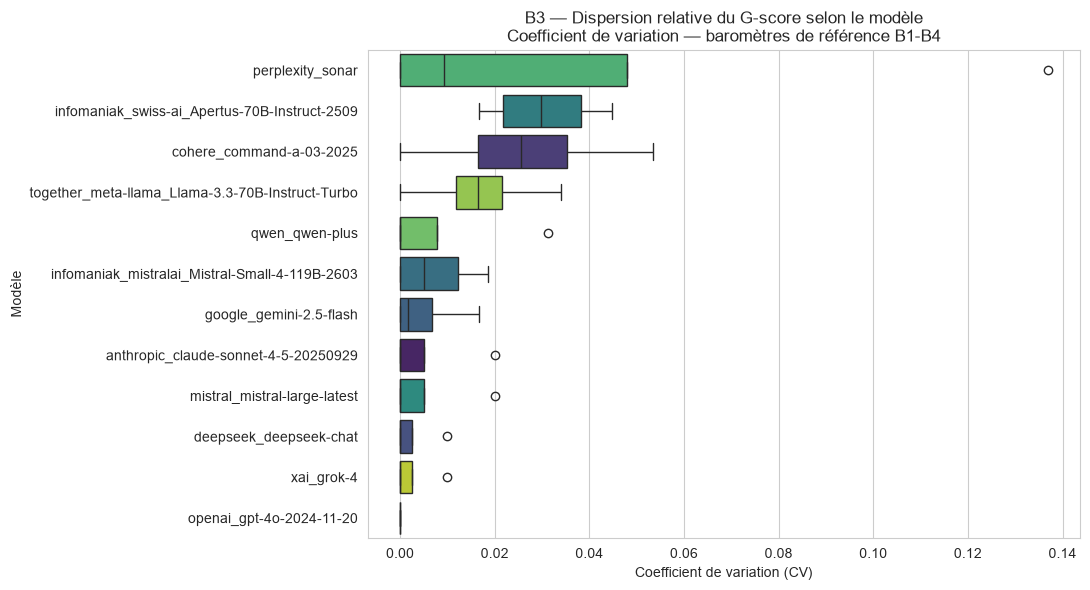

In [38]:
# Question : La variabilité relative du G-score diffère-t-elle selon les modèles ?

variabilite = (df_canonique[df_canonique['baromètre'].isin(baros_reference) ].groupby(['modèle', 'prompt_id'])['g_score']
    .agg(moyenne='mean',ecart_type='std').reset_index())

# Coefficient de variation
variabilite['cv'] = (variabilite['ecart_type'] /variabilite['moyenne'])

# Classement des modèles selon leur CV moyen
ordre_cv = (variabilite.groupby('modèle')['cv'].mean().sort_values(ascending=False).index)

# Maintenant la visualisation
fig, ax = plt.subplots(figsize=(11, 6))

sns.boxplot(data=variabilite, y='modèle', x='cv', order=ordre_cv, hue='modèle', palette='viridis', legend=False, ax=ax )

ax.set_title( "B3 — Dispersion relative du G-score selon le modèle\n" "Coefficient de variation — baromètres de référence B1-B4" )

ax.set_xlabel("Coefficient de variation (CV)")
ax.set_ylabel("Modèle")

plt.tight_layout()

plt.savefig('B3_dispersion_relative_G_modele.png',dpi=150)
plt.show()

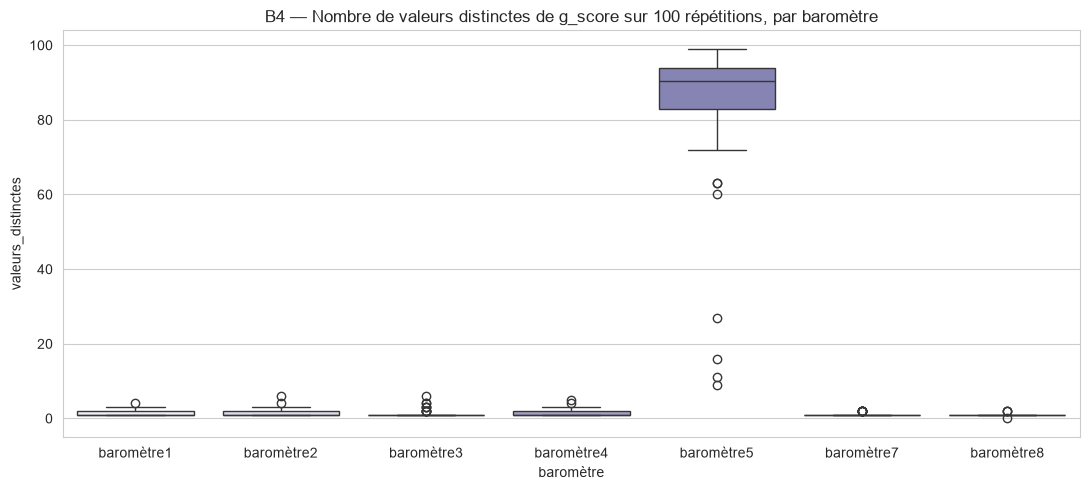

baromètre
baromètre1     1.437500
baromètre2     1.479167
baromètre3     1.458333
baromètre4     1.437500
baromètre5    82.166667
baromètre7     1.208333
baromètre8     1.041667
Name: valeurs_distinctes, dtype: float64


In [39]:
# à mettre en annexe, moins important que les autres
# B4 — Diversité des valeurs du G au cours des répétitions
# QUESTION : combien de valeurs différentes le score prend-il, prompt par prompt ?
# Permet de comparer visuellement si baromètre7/8 ressemblent à B1-4 ou à B5
reproductibilite = (df_canonique.groupby(['baromètre', 'modèle', 'prompt_id'])['g_score']
                     .agg(valeurs_distinctes='nunique').reset_index())
fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=reproductibilite, x='baromètre', y='valeurs_distinctes', order=ordre_baro,
            hue='baromètre', palette='Purples', legend=False, ax=ax)
ax.set_title("B4 — Nombre de valeurs distinctes de g_score sur 100 répétitions, par baromètre")
plt.tight_layout()
plt.savefig('B4_annexe_valeurs_distinctes.png', dpi=150)
plt.show()
print(reproductibilite.groupby('baromètre')['valeurs_distinctes'].mean().reindex(ordre_baro))

### Synthèse du bloc B

Les analyses montrent que la reproductibilité du G-score varie selon les modèles. L'évolution des scores au fil des répétitions et leur dispersion mettent en évidence des comportements différents entre modèles. La corrélation intraclasse permet de compléter cette analyse en quantifiant directement la reproductibilité des répétitions.

Les résultats de cette partie permettent ainsi d'identifier les modèles pour lesquels le G-score est relativement stable et ceux pour lesquels les répétitions présentent davantage de variabilité.

### BLOC C — Sources de variabilité

L'objectif  de ce bloc est de distinguer les différences de G-score entre les prompts de la variabilité observée entre les répétitions d'un même prompt.

#### C1. Variabilité du G-score selon le modèle, le prompt et le baromètre



In [40]:
clean = df_canonique[(df_canonique['baromètre'].isin(baros_reference)) & (df_canonique['g_score'].notna())]

variance_totale = clean['g_score'].var()

moyennes_modele = clean.groupby('modèle')['g_score'].mean()
moyennes_prompt = clean.groupby('prompt_id')['g_score'].mean()
moyennes_baro = clean.groupby('baromètre')['g_score'].mean()

var_entre_modeles = moyennes_modele.var()
var_entre_prompts = moyennes_prompt.var()
var_entre_baro = moyennes_baro.var()

print("\n Décomposition exploratoire de la variabilité ")
print(f"Variance totale du G-score : {variance_totale:.6f}")
print(f"Variance des moyennes entre modèles : {var_entre_modeles:.6f}")
print(f"Variance des moyennes entre prompts : {var_entre_prompts:.6f}")
print(f"Variance des moyennes entre baromètres : {var_entre_baro:.6f}")

print("\n Étendue des moyennes")
print(f"Modèles    : {moyennes_modele.min():.4f} → {moyennes_modele.max():.4f}")
print(f"Prompts    : {moyennes_prompt.min():.4f} → {moyennes_prompt.max():.4f}")
print(f"Baromètres : {moyennes_baro.min():.4f} → {moyennes_baro.max():.4f}")


 Décomposition exploratoire de la variabilité 
Variance totale du G-score : 0.000269
Variance des moyennes entre modèles : 0.000014
Variance des moyennes entre prompts : 0.000006
Variance des moyennes entre baromètres : 0.000000

 Étendue des moyennes
Modèles    : 0.5867 → 0.6000
Prompts    : 0.5947 → 0.5999
Baromètres : 0.5973 → 0.5989


##### Interprétation 

Sur les baromètres de référence B1-B4, la variance totale du G-score est de 0,000269.

Les différences entre modèles semblent constituer la source de variation la plus marquée parmi les trois facteurs étudiés. La variance des moyennes entre modèles est de 0,000014, avec des moyennes allant de 0,5867 à 0,6000.

La variabilité entre prompts est plus faible, avec une variance de 0,000006. Les moyennes des prompts s'étendent de 0,5947 à 0,5999.

Enfin, les différences entre les baromètres de référence sont très faibles : la variance des moyennes est inférieure à 0,000001 et les moyennes varient seulement de 0,5973 à 0,5989.

Ainsi, sur les campagnes de référence, les différences observées entre modèles sont plus importantes que celles entre prompts ou entre baromètres. Cette analyse reste toutefois descriptive, elle compare la dispersion des moyennes et ne constitue pas une décomposition formelle de la variance totale.

### C2. Comparaison globale des modèles (test Kruskal-Wallis)

In [41]:
# Question : les distributions du G-score sont-elles identiques pour tous les modèles ?
#Le test de Kruskal-Wallis permet de vérifier si la distribution du G-score diffère significativement 
# entre les modèles sur les baromètres de référence B1-B4.

groupes_modeles = [g['g_score'].dropna().values for _, g in clean.groupby('modèle')]

h_stat, p_kw = stats.kruskal(*groupes_modeles)

print(f"Statistique H : {h_stat:.2f}")
print(f"p-value : {p_kw:.2e}")

Statistique H : 877.38
p-value : 4.52e-181


In [42]:
#  Statistiques descriptives du G-score par modèle (nouveau)
# Période de référence B1-B4
reference_df = df_canonique[df_canonique["baromètre"].isin(baros_reference)].dropna(subset=["g_score"])

stats_modele = (
    reference_df.groupby("modèle")["g_score"]
    .agg(n="count",moyenne="mean",mediane="median",ecart_type="std")
    .sort_values("moyenne", ascending=False)
)

print("Statistiques descriptives du G-score par modèle, période de référence")
print(stats_modele.round(4))

Statistiques descriptives du G-score par modèle, période de référence
                                                     n  moyenne  mediane  \
modèle                                                                     
openai_gpt-4o-2024-11-20                          1600   0.6000      0.6   
deepseek_deepseek-chat                            1598   0.5999      0.6   
xai_grok-4                                        1579   0.5999      0.6   
google_gemini-2.5-flash                           1599   0.5998      0.6   
anthropic_claude-sonnet-4-5-20250929              1599   0.5997      0.6   
mistral_mistral-large-latest                      1598   0.5997      0.6   
infomaniak_mistralai_Mistral-Small-4-119B-2603    1600   0.5997      0.6   
qwen_qwen-plus                                    1596   0.5992      0.6   
together_meta-llama_Llama-3.3-70B-Instruct-Turbo  1599   0.5987      0.6   
cohere_command-a-03-2025                          1544   0.5981      0.6   
infomaniak_swiss-a

### C3. Comparaisons entre modèles (Dunn + Holm + Cliff's delta)

Le test de Dunn permet d'identifier les paires de modèles présentant des différences statistiquement significatives après le test de Kruskal-Wallis. La correction de Holm est utilisée pour tenir compte des comparaisons multiples. Le Cliff's delta complète les p-values en donnant une mesure de l'ampleur des différences.

In [43]:
# On commence par définier la fonction pour le Cliff's delta

def cliffs_delta(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    n_x = len(x)
    n_y = len(y)

    wins = sum(a > b for a in x for b in y)
    losses = sum(a < b for a in x for b in y)

    return (wins - losses) / (n_x * n_y)


def interpretation_effet(d):
    d_abs = abs(d)

    if d_abs < 0.147:
        return "négligeable"
    elif d_abs < 0.33:
        return "faible"
    elif d_abs < 0.474:
        return "modéré"
    else:
        return "important"

In [44]:
# Test de Dunn
reference_df = (df_canonique[df_canonique["baromètre"].isin(baros_reference)].dropna(subset=["g_score"]))
resultat_dunn = spc.posthoc_dunn(reference_df,val_col="g_score",group_col="modèle",p_adjust="holm")
display(resultat_dunn.round(4))

,anthropic_claude-sonnet-4-5-20250929,cohere_command-a-03-2025,deepseek_deepseek-chat,google_gemini-2.5-flash,infomaniak_mistralai_Mistral-Small-4-119B-2603,infomaniak_swiss-ai_Apertus-70B-Instruct-2509,mistral_mistral-large-latest,openai_gpt-4o-2024-11-20,perplexity_sonar,qwen_qwen-plus,together_meta-llama_Llama-3.3-70B-Instruct-Turbo,xai_grok-4
anthropic_claude-sonnet-4-5-20250929,1.0000,1.0000,1.0000,1.0000,1.0000,0.000,1.0000,1.0000,0.0,1.0,0.2593,1.0000
cohere_command-a-03-2025,1.0000,1.0000,0.9660,1.0000,1.0000,0.000,1.0000,0.6649,0.0,1.0,1.0000,0.9660
deepseek_deepseek-chat,1.0000,0.9660,1.0000,1.0000,1.0000,0.000,1.0000,1.0000,0.0,1.0,0.0635,1.0000
google_gemini-2.5-flash,1.0000,1.0000,1.0000,1.0000,1.0000,0.000,1.0000,1.0000,0.0,1.0,0.1015,1.0000
infomaniak_mistralai_Mistral-Small-4-119B-2603,1.0000,1.0000,1.0000,1.0000,1.0000,0.000,1.0000,1.0000,0.0,1.0,0.3857,1.0000
infomaniak_swiss-ai_Apertus-70B-Instruct-2509,0.0000,0.0000,0.0000,0.0000,0.0000,1.000,0.0000,0.0000,0.0,0.0,0.0010,0.0000
mistral_mistral-large-latest,1.0000,1.0000,1.0000,1.0000,1.0000,0.000,1.0000,1.0000,0.0,1.0,0.2593,1.0000
openai_gpt-4o-2024-11-20,1.0000,0.6649,1.0000,1.0000,1.0000,0.000,1.0000,1.0000,0.0,1.0,0.0378,1.0000
perplexity_sonar,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.0000,0.0000,1.0,0.0,0.0000,0.0000
qwen_qwen-plus,1.0000,1.0000,1.0000,1.0000,1.0000,0.000,1.0000,1.0000,0.0,1.0,1.0000,1.0000


In [45]:
# Paires de modèles présentant une différence significative

paires_sig = []

modeles = resultat_dunn.columns.tolist()

for i, m1 in enumerate(modeles):
    for m2 in modeles[i + 1:]:

        p = resultat_dunn.loc[m1, m2]

        if p < 0.05:

            x = reference_df[
                reference_df["modèle"] == m1
            ]["g_score"].values

            y = reference_df[
                reference_df["modèle"] == m2
            ]["g_score"].values

            d = cliffs_delta(x, y)

            paires_sig.append({"modèle_1": m1,"modèle_2": m2, "p_value": p, "cliffs_delta": d, "amplitude": interpretation_effet(d)})

resultats_cliff = pd.DataFrame(paires_sig)

resultats_cliff = resultats_cliff.sort_values("cliffs_delta",key=lambda x: x.abs(),ascending=False)

print(
    f"Nombre de paires significatives : "
    f"{len(resultats_cliff)} / "
    f"{len(modeles) * (len(modeles) - 1) // 2}")
display(resultats_cliff)

Nombre de paires significatives : 22 / 66


,modèle_1,modèle_2,p_value,cliffs_delta,amplitude
17,openai_gpt-4o-2024-11-20,perplexity_sonar,3.592289e-107,0.090625,négligeable
5,deepseek_deepseek-chat,perplexity_sonar,1.198697e-105,0.090029,négligeable
21,perplexity_sonar,xai_grok-4,5.257798e-105,-0.090022,négligeable
7,google_gemini-2.5-flash,perplexity_sonar,3.111374e-104,0.089384,négligeable
1,anthropic_claude-sonnet-4-5-20250929,perplexity_sonar,2.248205e-101,0.088244,négligeable
16,mistral_mistral-large-latest,perplexity_sonar,2.398933e-101,0.088242,négligeable
9,infomaniak_mistralai_Mistral-Small-4-119B-2603,perplexity_sonar,5.266658e-100,0.087651,négligeable
19,perplexity_sonar,qwen_qwen-plus,1.492036e-91,-0.084105,négligeable
3,cohere_command-a-03-2025,perplexity_sonar,8.164816e-84,0.080255,négligeable
20,perplexity_sonar,together_meta-llama_Llama-3.3-70B-Instruct-Turbo,2.157605e-77,-0.077575,négligeable


In [46]:
# Tableau final pour l'annexe :
# comparaisons significatives après correction de Holm
tableau_annexe_dunn = resultats_cliff.copy()

tableau_annexe_dunn = tableau_annexe_dunn[
    ["modèle_1", "modèle_2", "p_value", "cliffs_delta", "amplitude"]
].copy()

tableau_annexe_dunn = tableau_annexe_dunn.rename(columns={
    "modèle_1": "Modèle 1",
    "modèle_2": "Modèle 2",
    "p_value": "p-value (Holm)",
    "cliffs_delta": "Cliff's delta",
    "amplitude": "Amplitude"
})

tableau_annexe_dunn["p-value (Holm)"] = (
    tableau_annexe_dunn["p-value (Holm)"].map(lambda x: f"{x:.3e}")
)

tableau_annexe_dunn["Cliff's delta"] = (
    tableau_annexe_dunn["Cliff's delta"].map(lambda x: f"{x:.4f}")
)

display(tableau_annexe_dunn)

,Modèle 1,Modèle 2,p-value (Holm),Cliff's delta,Amplitude
17,openai_gpt-4o-2024-11-20,perplexity_sonar,3.592e-107,0.0906,négligeable
5,deepseek_deepseek-chat,perplexity_sonar,1.199e-105,0.0900,négligeable
21,perplexity_sonar,xai_grok-4,5.258e-105,-0.0900,négligeable
7,google_gemini-2.5-flash,perplexity_sonar,3.111e-104,0.0894,négligeable
1,anthropic_claude-sonnet-4-5-20250929,perplexity_sonar,2.248e-101,0.0882,négligeable
16,mistral_mistral-large-latest,perplexity_sonar,2.399e-101,0.0882,négligeable
9,infomaniak_mistralai_Mistral-Small-4-119B-2603,perplexity_sonar,5.267e-100,0.0877,négligeable
19,perplexity_sonar,qwen_qwen-plus,1.492e-91,-0.0841,négligeable
3,cohere_command-a-03-2025,perplexity_sonar,8.165e-84,0.0803,négligeable
20,perplexity_sonar,together_meta-llama_Llama-3.3-70B-Instruct-Turbo,2.158e-77,-0.0776,négligeable


In [47]:
tableau_annexe_dunn.to_csv("annexe_Dunn_Holm_Cliff_delta.csv",index=False)

#### C6. Variabilité inter-prompts et intra-prompt

In [48]:
# Question : les prompts ont-ils des niveaux moyens différents et,
# pour un même prompt, les répétitions produisent-elles des scores variables ?
reference_df = df_canonique[df_canonique['baromètre'].isin(baros_reference)].dropna(subset=['g_score']).copy()

print("Variabilité INTER-prompts ")
inter = (reference_df.groupby(['modèle', 'prompt_id'])['g_score'].agg(moyenne='mean', ecart_type='std', n='count')
         .reset_index())
print(inter.to_string(index=False))

ecart_inter = (inter.groupby('modèle')['moyenne'].agg(lambda x: x.max() - x.min()))
print("\nÉcart entre le prompt le plus haut et le plus bas, par modèle :")
print(ecart_inter.sort_values(ascending=False).to_string())


print("\n Variabilité INTRA-prompt ")
intra = (reference_df.groupby(['modèle', 'prompt_id'])['g_score'].std().reset_index(name='ecart_type_intra'))

print("Écart-type intra-prompt par modèle et par prompt :")
print(intra.to_string(index=False))

resume_intra = (intra.groupby('modèle')['ecart_type_intra']
                .agg(moyenne='mean', mediane='median', minimum='min', maximum='max')
                .sort_values('moyenne'))

print("\nRésumé de la dispersion intra-prompt par modèle :")
print(resume_intra.to_string())


Variabilité INTER-prompts 
                                          modèle     prompt_id  moyenne  ecart_type   n
            anthropic_claude-sonnet-4-5-20250929 NM-WEEKLY-Q01 0.600000    0.000000 400
            anthropic_claude-sonnet-4-5-20250929 NM-WEEKLY-Q02 0.600000    0.000000 400
            anthropic_claude-sonnet-4-5-20250929 NM-WEEKLY-Q03 0.598800    0.011955 400
            anthropic_claude-sonnet-4-5-20250929 NM-WEEKLY-Q04 0.600000    0.000000 399
                        cohere_command-a-03-2025 NM-WEEKLY-Q01 0.600000    0.000000 392
                        cohere_command-a-03-2025 NM-WEEKLY-Q02 0.598462    0.017496 390
                        cohere_command-a-03-2025 NM-WEEKLY-Q03 0.599043    0.013191 376
                        cohere_command-a-03-2025 NM-WEEKLY-Q04 0.594819    0.031813 386
                          deepseek_deepseek-chat NM-WEEKLY-Q01 0.600000    0.000000 400
                          deepseek_deepseek-chat NM-WEEKLY-Q02 0.600000    0.000000 400
     

##### Synthèse pour le bloc C  :
L'analyse distingue la variabilité liée au choix du prompt de celle observée lors des répétitions d'un même prompt. Dans les campagnes de référence, les moyennes du G-score sont globalement proches entre prompts pour la majorité des modèles. Cependant, certaines combinaisons modèle–prompt présentent une variabilité plus importante, notamment Perplexity avec le prompt Q04, qui présente à la fois le plus grand écart entre prompts et la plus forte dispersion intra-prompt. Ces résultats suggèrent que la reproductibilité du G-score n'est pas totalement homogène selon les modèles et les prompts. Cette observation justifie une analyse complémentaire de la reproductibilité, notamment à l'aide de l'ICC.

### BLOC D — Analyse de la variation observée au baromètre 5

#### D1. Contexte de la campagne B5

**Objectif :** caractériser le comportement du G-score lors de la campagne B5, en tenant compte de son contexte opérationnel particulier.

La campagne B5 s'est déroulée dans des conditions différentes des campagnes précédentes : plusieurs problèmes d'exécution ont été rencontrés chez certains providers et plusieurs relances ont été nécessaires. Cette période correspondait également à une phase de consolidation technique du backend.

B5 est donc conservé dans l'analyse pour assurer la traçabilité et mesurer précisément la rupture observée, mais il est traité séparément du régime longitudinal principal constitué des campagnes comparables. Les analyses statistiques permettent de caractériser l'ampleur et l'hétérogénéité de la variation du G-score en B5, sans permettre d'en établir rétrospectivement l'origine causale.

#### D2. Distribution du G-score : période de référence vs B5
**Objectif :** comparer visuellement
 la distribution du G-score entre les campagnes de référence B1-B4 et la campagne B5 afin de caractériser la rupture observée.

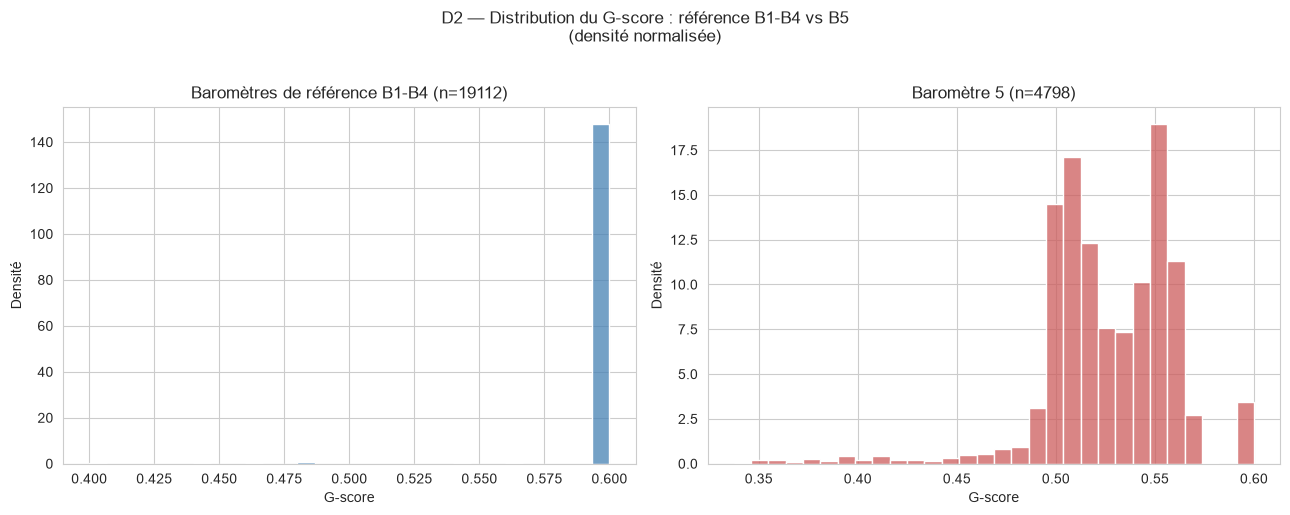

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

stable = df_canonique[df_canonique['baromètre'].isin(baros_reference)]['g_score'].dropna()

b5 = df_canonique[df_canonique['baromètre'] == 'baromètre5']['g_score'].dropna()

sns.histplot(stable, bins=30, ax=axes[0], color='steelblue', stat='density')
axes[0].set_title(f"Baromètres de référence B1-B4 (n={len(stable)})")
axes[0].set_xlabel("G-score")
axes[0].set_ylabel("Densité")
sns.histplot(b5, bins=30, ax=axes[1], color='indianred', stat='density')
axes[1].set_title(f"Baromètre 5 (n={len(b5)})")
axes[1].set_xlabel("G-score")
axes[1].set_ylabel("Densité")

fig.suptitle("D2 — Distribution du G-score : référence B1-B4 vs B5\n" "(densité normalisée)", y=1.02 )

plt.tight_layout()
plt.savefig('D2_distributions_avant_apres.png', dpi=150)
plt.show()

### Interprétation

La distribution du G-score présente une rupture nette en B5 par rapport aux campagnes de référence B1-B4. Le niveau du score est globalement plus faible en B5, ce qui met en évidence un changement de régime au cours de cette campagne. Cette différence descriptive sera ensuite quantifiée à l'aide d'un test statistique et d'une mesure de taille d'effet.

Compte tenu du contexte opérationnel particulier de B5, cette rupture est interprétée comme un événement atypique. Les données disponibles permettent d'en caractériser l'ampleur, mais ne permettent pas d'en déterminer rétrospectivement l'origine causale.

#### Comparaison statistique du G-score (Référence vs B5): Mann-Whitney

On souhaite déterminer si la distribution du G-score diffère statistiquement entre les campagnes de référence B1-B4 et B5.
Le test de Mann-Whitney évalue l'existence d'une différence entre les deux distributions. L'ampleur de cette différence sera ensuite quantifiée avec le Cliff's comme précédemment

In [50]:
reference = df_canonique[df_canonique['baromètre'].isin(baros_reference)]['g_score'].dropna()
b5 = df_canonique[df_canonique['baromètre'] == 'baromètre5']['g_score'].dropna()
stat, p = stats.mannwhitneyu(reference, b5, alternative='two-sided')

print("Mann-Whitney : référence B1-B4 vs B5")
print(f"U = {stat:.0f}")
print(f"p = {p:.2e}")
print(f"Moyenne référence B1-B4 : {reference.mean():.4f}")
print(f"Moyenne B5             : {b5.mean():.4f}")

Mann-Whitney : référence B1-B4 vs B5
U = 89243586
p = 0.00e+00
Moyenne référence B1-B4 : 0.5982
Moyenne B5             : 0.5266


##### Interprétation

Le test de Mann-Whitney met en évidence une différence statistiquement significative du G-score entre la période de référence B1-B4 et B5. Ce résultat confirme que la différence observée dans les distributions ne semble pas être due uniquement aux fluctuations aléatoires des observations.

!! Le test établit l'existence d'une différence entre les deux périodes, mais ne permet pas d'en déterminer l'origine ni d'en mesurer directement l'amplitude. Cette dernière est étudiée avec le Cliff's delta.

#### D4. Amplitude de la rupture : Cliff's delta entre la référence et B5


Le Cliff's delta complète le test de Mann-Whitney en quantifiant l'ampleur de la différence entre les distributions du G-score en B1-B4 et en B5.
Un intervalle de confiance à 95 % est obtenu par bootstrap afin d'évaluer la précision de l'estimation
D3 nous dit :s' il y a une différence alors que D4 nous dit : quelle est l'ampleur de cette différence ? 

In [51]:
def cliffs_delta_rapide(x, y):
   
    x = np.asarray(x)
    y = np.asarray(y)

    n_x = len(x)
    n_y = len(y)

    # Nombre de paires où x > y et x < y
    wins = np.searchsorted(
        np.sort(y), x, side="left"
    ).sum()

    losses = (
        n_y
        - np.searchsorted(
            np.sort(y), x, side="right"
        )
    ).sum()

    return (wins - losses) / (n_x * n_y)


def cliffs_delta_ic_bootstrap_rapide(
    x,
    y,
    n_iterations=500,
    niveau=0.95,
    seed=42
):
    rng = np.random.default_rng(seed)

    deltas = []

    for _ in range(n_iterations):

        x_ech = rng.choice(
            x,
            size=len(x),
            replace=True
        )

        y_ech = rng.choice(
            y,
            size=len(y),
            replace=True
        )

        deltas.append(
            cliffs_delta_rapide(
                x_ech,
                y_ech
            )
        )

    alpha = (1 - niveau) / 2

    delta = cliffs_delta_rapide(x, y)

    ic_inf = np.percentile(
        deltas,
        alpha * 100
    )

    ic_sup = np.percentile(
        deltas,
        (1 - alpha) * 100
    )

    return delta, ic_inf, ic_sup


# Calcul du Cliff's delta et de son intervalle de confiance

delta, ic_inf, ic_sup = cliffs_delta_ic_bootstrap_rapide(reference.values,b5.values)
print("Cliff's delta : référence B1-B4 vs B5 ")
print(f"δ = {delta:.4f}")
print(f"IC 95 % : [{ic_inf:.4f} ; {ic_sup:.4f}]")
print(f"Amplitude : {interpretation_effet(delta)}")

Cliff's delta : référence B1-B4 vs B5 
δ = 0.9464
IC 95 % : [0.9408 ; 0.9517]
Amplitude : important


##### Interprétation

Le Cliff's delta est de 0,9464, avec un intervalle de confiance à 95 % compris entre 0,9408 et 0,9517. L'amplitude de l'effet est donc considérée comme importante.

La valeur très élevée du Cliff's delta indique que les distributions du G-score en B1-B4 et en B5 sont fortement séparées. L'intervalle de confiance est également très resserré, ce qui montre que cette estimation est stable.

Ainsi, la différence observée au baromètre 5 ne correspond pas uniquement à une différence statistiquement détectable : elle représente également une rupture importante en termes d'amplitude.

Cette analyse confirme donc les résultats du test de Mann-Whitney et renforce l'hypothèse d'un comportement nettement différent du G-score lors de la campagne B5.

####  D5. Hétérogénéité de la rupture B5 selon le modèle
J'ai rajouté ce bloc car c'est important parce que D ne doit pas seulement dire : B5 est différent.
Il faut aussi savoir : Est-ce que B5 affecte tous les modèles de la même manière ?

In [52]:
# Cette analyse est descriptive : elle permet d'identifier
# les différences de comportement entre modèles avant leur
# évaluation formelle dans le modèle mixte.

df_d5 = (df_canonique[ df_canonique["baromètre"].isin( baros_reference + ["baromètre5"])]
    .dropna(subset=["g_score"]).copy())

df_d5["periode"] = np.where(df_d5["baromètre"].isin(baros_reference),"Référence","B5")

ordre_groupes = ["Référence", "B5"]
resume_d5 = (df_d5.groupby(["modèle", "periode"])["g_score"]
    .agg(moyenne="mean",mediane="median",ecart_type="std",n="count").round(4))

print(" D5 — G-score par modèle : Référence vs B5 ")
print(resume_d5)


 D5 — G-score par modèle : Référence vs B5 
                                                            moyenne  mediane  \
modèle                                           periode                       
anthropic_claude-sonnet-4-5-20250929             B5          0.5255   0.5273   
                                                 Référence   0.5997   0.6000   
cohere_command-a-03-2025                         B5          0.5263   0.5284   
                                                 Référence   0.5981   0.6000   
deepseek_deepseek-chat                           B5          0.5339   0.5344   
                                                 Référence   0.5999   0.6000   
google_gemini-2.5-flash                          B5          0.5255   0.5237   
                                                 Référence   0.5998   0.6000   
infomaniak_mistralai_Mistral-Small-4-119B-2603   B5          0.5293   0.5243   
                                                 Référence   0.5997   0.6000

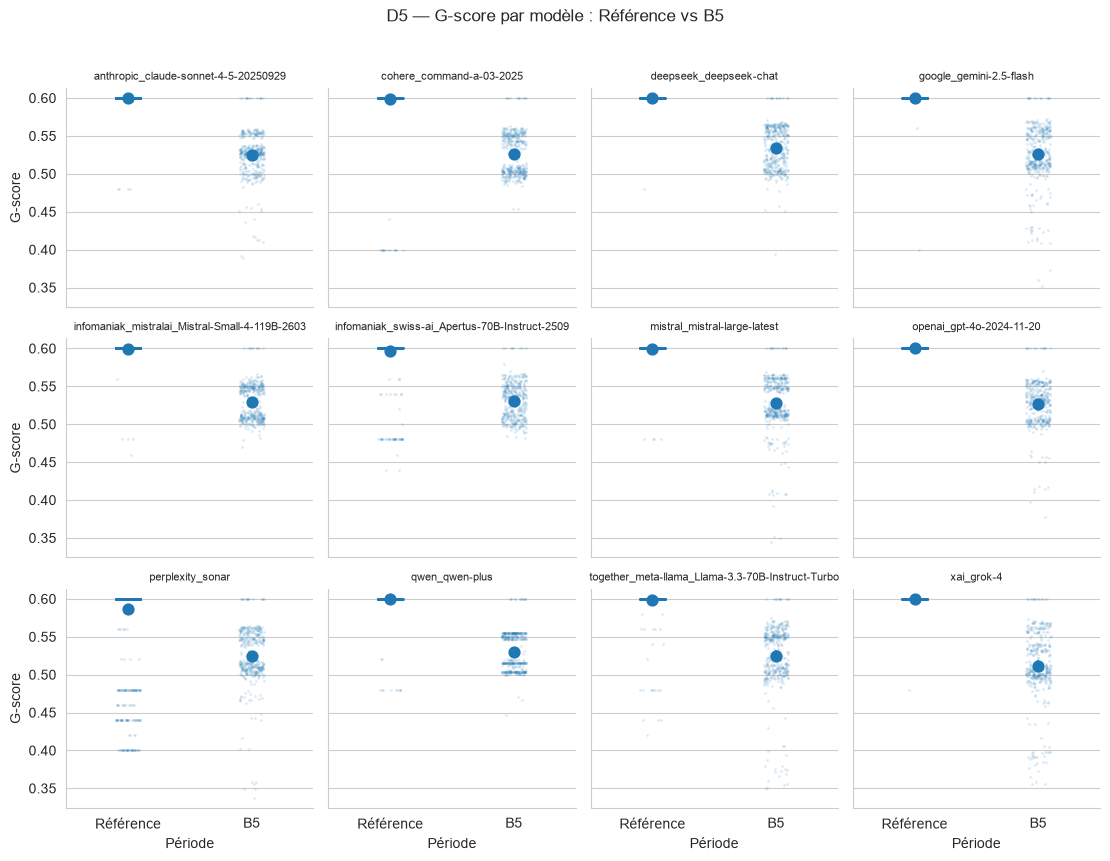

In [53]:
g = sns.FacetGrid(df_d5,col="modèle",col_wrap=4,height=2.8,sharey=True)

# Points individuels
g.map_dataframe(sns.stripplot,x="periode",y="g_score",order=ordre_groupes,alpha=0.15,size=2)
# avec la version stripplot, on peut voir plus la dispersion réelle des G-scores, si les observations sont concentrées ou dispersées,
# si B presente d'avantage de variabilité 

# moyenne + IC 95 %
g.map_dataframe(sns.pointplot,x="periode",y="g_score",order=ordre_groupes,errorbar=("ci", 95),join=False)

g.set_titles("{col_name}", size=8)
g.set_axis_labels("Période", "G-score")

g.fig.suptitle("D5 — G-score par modèle : Référence vs B5",y=1.02)
plt.tight_layout()
plt.savefig("D5_par_modele_B5.png", dpi=150,bbox_inches="tight" )
plt.show()

##### Synthèse du bloc D

Les résultats montrent une rupture nette du G-score lors de la campagne B5 par rapport aux baromètres de référence B1-B4. La différence entre les deux périodes est statistiquement significative selon le test de Mann-Whitney.

L'ampleur de cette différence est importante : le Cliff's delta est de 0,9464, avec un intervalle de confiance à 95 % de **[0,9408 ; 0,9517]**. La différence entre les distributions est donc importante en pratique et pas uniquement statistiquement détectable.

L'analyse par modèle montre que cette baisse concerne les 12 modèles étudiés. En B5, les moyennes du G-score se situent entre **0,5118 et 0,5339**, alors qu'elles sont proches de **0,60** sur la période de référence. La baisse est particulièrement marquée pour **xAI Grok-4**, tandis qu'elle est moins importante pour **DeepSeek et Perplexity**.

La dispersion du G-score augmente également en B5. Par exemple, l'écart-type passe de **0,0030 à 0,0287 pour DeepSeek** et de **0,0030 à 0,0464 pour xAI Grok-4**.

Dans l'ensemble, B5 apparaît donc comme une **rupture transversale**, affectant l'ensemble des modèles et s'accompagnant à la fois d'une baisse du niveau moyen du G-score et d'une augmentation de sa variabilité. Ces résultats restent descriptifs et ne permettent pas d'établir la cause de cette rupture.

### E. Structure de dépendance et variabilité des répétitions
L'objectif de cette partie est de répondre à une question méthodologique avant de construire le modèle mixte 

On commence par le première question:
Est-ce que les répétitions d'un même prompt peuvent être considérées comme des observations indépendantes ?


#### E1. autocorrélation

In [54]:
reference_df = df_canonique[df_canonique["baromètre"].isin(baros_reference)].dropna(subset=["g_score"]).copy()

corr_repetitions = []

for (modele, prompt, baro), groupe in reference_df.groupby(
    ["modèle", "prompt_id", "baromètre"]):
    valeurs = (groupe.sort_values("repetition_index")["g_score"].values)

    if len(valeurs) > 1 and np.std(valeurs) > 0:
        corr_repetitions.append({
            "modèle": modele,
            "prompt_id": prompt,
            "baromètre": baro,
            "autocorrelation": pd.Series(valeurs).autocorr()})

df_dependance = pd.DataFrame(corr_repetitions).dropna(subset=["autocorrelation"])

print("E1 — Dépendance entre les répétitions")
print(df_dependance["autocorrelation"].describe())

print("\n Moyenne de l'autocorrélation par modèle")
print(df_dependance.groupby("modèle")["autocorrelation"].mean().sort_values().round(4))



E1 — Dépendance entre les répétitions
count    63.000000
mean      0.141618
std       0.377299
min      -0.113504
25%      -0.028525
50%      -0.012195
75%      -0.010204
max       1.000000
Name: autocorrelation, dtype: float64

 Moyenne de l'autocorrélation par modèle
modèle
perplexity_sonar                                   -0.0337
infomaniak_swiss-ai_Apertus-70B-Instruct-2509      -0.0208
together_meta-llama_Llama-3.3-70B-Instruct-Turbo   -0.0179
infomaniak_mistralai_Mistral-Small-4-119B-2603     -0.0157
qwen_qwen-plus                                      0.1960
mistral_mistral-large-latest                        0.2397
cohere_command-a-03-2025                            0.2622
anthropic_claude-sonnet-4-5-20250929                0.3196
google_gemini-2.5-flash                             0.3265
deepseek_deepseek-chat                              0.6633
xai_grok-4                                          0.6633
Name: autocorrelation, dtype: float64


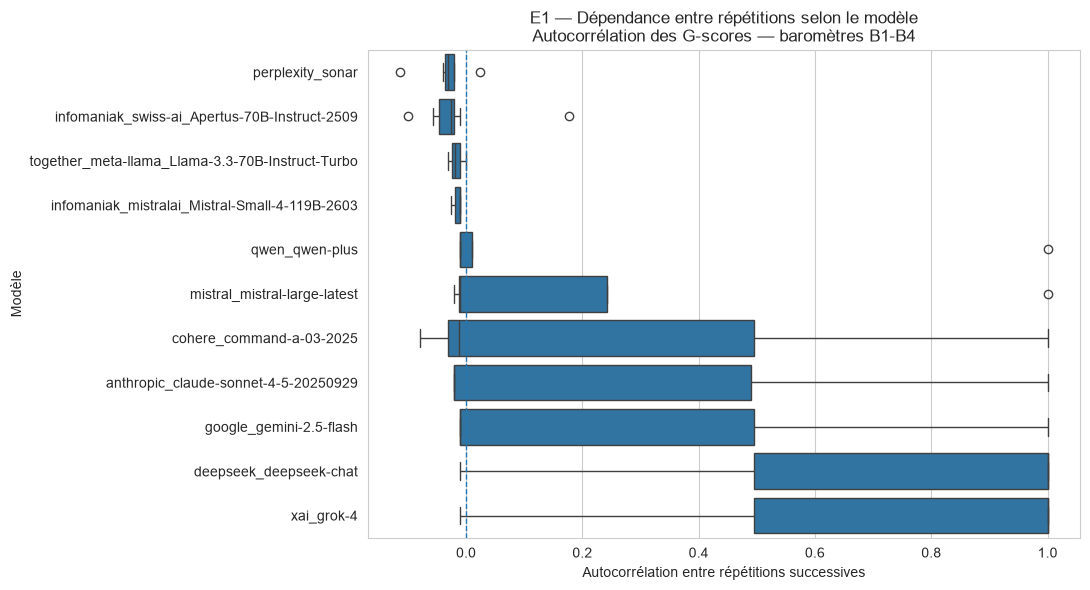

In [55]:
plt.figure(figsize=(11, 6))

ordre = (df_dependance.groupby("modèle")["autocorrelation"].mean().sort_values().index)
sns.boxplot(data=df_dependance,x="autocorrelation",y="modèle",order=ordre)
plt.axvline(0, linestyle="--", linewidth=1)
plt.title("E1 — Dépendance entre répétitions selon le modèle\n"
    "Autocorrélation des G-scores — baromètres B1-B4")

plt.xlabel("Autocorrélation entre répétitions successives")
plt.ylabel("Modèle")

plt.tight_layout()

plt.savefig("E1_dependance_repetitions.png",dpi=150,bbox_inches="tight")

plt.show()

##### Interprétation

L'autocorrélation médiane est proche de zéro (**-0,012**), indiquant une dépendance généralement faible entre deux répétitions successives. Cependant, cette dépendance varie selon les modèles, avec des valeurs plus élevées pour **DeepSeek et Grok-4 (0,663)**.

Ces résultats restent exploratoires et justifient la prise en compte de la structure répétée des observations dans l'analyse par modèle mixte.

#### E2. Décomposition exacte de la variabilité inter-prompt / intra-prompt

In [56]:
# But : séparer précisément la variabilité du G-score entre les prompts
# de celle observée entre les répétitions d'un même prompt. Cette décomposition
# permet de quantifier la contribution de chaque niveau de la structure répétée avant de construire le modèle mixte.

reference_df = df_canonique[df_canonique['baromètre'].isin(baros_reference)].dropna(subset=['g_score']).copy()

moyenne_generale = reference_df['g_score'].mean()
groupes = reference_df.groupby('prompt_id')['g_score']
effectifs = groupes.size()
moyennes = groupes.mean()

ss_total = ((reference_df['g_score'] - moyenne_generale) ** 2).sum()
ss_inter = (effectifs * (moyennes - moyenne_generale) ** 2).sum()
ss_intra = sum(((g - g.mean()) ** 2).sum() for _, g in groupes)

part_inter = ss_inter / ss_total
part_intra = ss_intra / ss_total

print("E2 — Décomposition exacte de la variabilité ")
print(f"Somme des carrés totale       : {ss_total:.6f}")
print(f"Somme des carrés inter-prompt : {ss_inter:.6f}")
print(f"Somme des carrés intra-prompt : {ss_intra:.6f}")
print(f"Vérification SS totale        : {ss_inter + ss_intra:.6f}")
print(f"Part inter-prompt             : {part_inter:.2%}")
print(f"Part intra-prompt             : {part_intra:.2%}")
print(f"Somme des proportions         : {part_inter + part_intra:.2%}")

E2 — Décomposition exacte de la variabilité 
Somme des carrés totale       : 5.135070
Somme des carrés inter-prompt : 0.083343
Somme des carrés intra-prompt : 5.051727
Vérification SS totale        : 5.135070
Part inter-prompt             : 1.62%
Part intra-prompt             : 98.38%
Somme des proportions         : 100.00%


### Interprétation

La variabilité du G-score est principalement observée entre les répétitions d'un même prompt : elle représente **98,38 %** de la variabilité totale, contre seulement **1,62 %** associée aux différences entre prompts.

Les différences de niveau moyen entre prompts sont donc relativement faibles par rapport à la dispersion observée au sein d'un même prompt. Ce résultat confirme l'intérêt de tenir compte de la structure répétée des observations dans l'analyse statistique suivante. Mais on doit faire gaffe : ça ne signifie pas que le prompt est inutile dans le modèle. Même avec une petite variance inter-prompt, il faut tenir compte du fait que les répétitions d'un même prompt constituent des observations regroupées.

#### E3. Structure des observations et choix de l’unité de regroupement

Les observations présentent une structure répétée : les mêmes prompts sont évalués
avec plusieurs modèles et plusieurs baromètres, et chaque combinaison est répétée
plusieurs fois.

Cette structure peut être représentée comme :

**prompt × modèle × baromètre × répétition**

Les répétitions associées à un même prompt ne peuvent donc pas être considérées
comme totalement indépendantes. Le `prompt_id` est ainsi retenu comme unité de
regroupement pour le modèle mixte, afin de tenir compte de la variabilité propre
à chaque prompt.

Le modèle, le baromètre et leur interaction seront ensuite considérés comme
des effets fixes dans les analyses de la partie F.

In [57]:
# vérification de la structure des unités répétées
# Objectif : identifier l'unité de regroupement adaptée au modèle mixte.

reference_df = df_canonique[df_canonique["baromètre"].isin(baros_reference)].dropna(subset=["g_score"]).copy()

print("E3 — Structure des observations")

print(f"Nombre de prompts   : {reference_df['prompt_id'].nunique()}")
print(f"Nombre de modèles   : {reference_df['modèle'].nunique()}")
print(f"Nombre de baromètres : {reference_df['baromètre'].nunique()}")

# Nombre d'observations par prompt
repetitions_prompt = (reference_df.groupby("prompt_id").size())

print("\nObservations par prompt")
print(repetitions_prompt.describe().round(2))

print("\nNombre d'observations par prompt :")
print(repetitions_prompt.sort_index())

E3 — Structure des observations
Nombre de prompts   : 4
Nombre de modèles   : 12
Nombre de baromètres : 4

Observations par prompt
count       4.00
mean     4778.00
std        10.17
min      4770.00
25%      4770.75
50%      4775.00
75%      4782.25
max      4792.00
dtype: float64

Nombre d'observations par prompt :
prompt_id
NM-WEEKLY-Q01    4792
NM-WEEKLY-Q02    4771
NM-WEEKLY-Q03    4770
NM-WEEKLY-Q04    4779
dtype: int64


#### E4. Justification du modèle mixte

Les analyses précédentes montrent que les observations sont organisées autour de
prompts répétés et que la variabilité est principalement observée entre les
répétitions d'un même prompt.

Afin de tenir compte de cette structure, les analyses de la partie F utilisent
un modèle mixte avec le 'prompt_id' comme effet aléatoire. Le modèle et le
baromètre sont introduits comme effets fixes, ainsi que leur interaction lorsque
cela est nécessaire.

Cette approche permet d'estimer les effets d'intérêt tout en tenant compte du
regroupement des observations associé aux prompts.


Avant de commancer le Bloc F :

> **NB — Rôle complémentaire des analyses D et F**
>
> Les analyses **D et F sont complémentaires** et ne répondent pas exactement à la même question.
>
> - **D** répond à une question descriptive et non paramétrique : *B5 est-il significativement différent de la période de référence B1-B4, et quelle est l'ampleur de cette différence ?*
> - **F** approfondit cette analyse à l'aide d'un **modèle mixte**, en tenant compte de la structure répétée des observations et en évaluant si l'ampleur de la variation entre la référence et B5 diffère selon les modèles.
>
> Ainsi, **D caractérise la rupture**, tandis que **F la confirme et en étudie l'hétérogénéité dans un cadre de modélisation adapté à la structure des données**.



##### F. Modèle mixte, principe et application à l'étude

Les observations de cette étude ne sont pas toutes indépendantes : un même prompt
est répété plusieurs fois dans une même condition expérimentale. Les répétitions
associées à un même prompt peuvent donc partager certaines caractéristiques
communes.

Le modèle mixte permet de tenir compte de cette structure en combinant des
**effets fixes**, correspondant aux facteurs dont on souhaite mesurer l'effet,
et un **effet aléatoire** associé au prompt.

Dans notre cas, les effets fixes considérés sont le **modèle**, le **baromètre**
et leur **interaction modèle × baromètre**. Le `prompt_id` est utilisé comme
unité de regroupement afin de prendre en compte la dépendance entre les
observations associées à un même prompt.

La forme générale du modèle est :

$$
G_{ijkl}
=
\beta_0
+
\beta_1\,\mathrm{Modèle}_i
+
\beta_2\,\mathrm{Baromètre}_j
+
\beta_3\left(\mathrm{Modèle}_i \times \mathrm{Baromètre}_j\right)
+
u_k
+
\varepsilon_{ijkl}
$$

où :

- $G_{ijkl}$ représente le G-score observé ;
- $\beta_0$ représente l'intercept ;
- $\beta_1$ et $\beta_2$ représentent les effets fixes du modèle et du baromètre ;
- $\beta_3$ représente l'interaction entre le modèle et le baromètre ;
- $u_k$ représente l'effet aléatoire associé au prompt ;
- $\varepsilon_{ijkl}$ représente le terme d'erreur résiduel.

Cette modélisation complète les analyses précédentes en tenant explicitement
compte de la structure répétée des observations.


#### F1. Effet du modèle et du baromètre

Cette première modélisation est réalisée sur les baromètres de référence B1-B4.

L'objectif est de déterminer si le **modèle** et le **baromètre** sont associés au niveau du G-score, tout en tenant compte de la structure répétée des
observations grâce à un effet aléatoire associé au `prompt_id`.

Le modèle estimé est :

$$
G\text{-score} \sim \text{modèle} + \text{baromètre} + (1|\text{prompt\_id})
$$

Cette première étape permet d'identifier les effets principaux avant d'étudier
dans F2 si l'effet du baromètre varie selon le modèle.

In [58]:
reference_df = df_canonique[df_canonique['baromètre'].isin(baros_reference)].dropna(subset=['g_score']).copy()

reference_df['modèle'] = reference_df['modèle'].astype('category')
reference_df['baromètre'] = reference_df['baromètre'].astype('category')

modele_mixte_1 = mixedlm("g_score ~ C(modèle) + C(baromètre)",data=reference_df,groups=reference_df["prompt_id"])
resultat_mixte_1 = modele_mixte_1.fit(reml=True)
print(resultat_mixte_1.summary())

                                  Mixed Linear Model Regression Results
Model:                             MixedLM                 Dependent Variable:                 g_score   
No. Observations:                  19112                   Method:                             REML      
No. Groups:                        4                       Scale:                              0.0003    
Min. group size:                   4770                    Log-Likelihood:                     51988.8266
Max. group size:                   4792                    Converged:                          Yes       
Mean group size:                   4778.0                                                                
---------------------------------------------------------------------------------------------------------
                                                              Coef.  Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------

##### Interprétation

Sur les baromètres de référence B1-B4, le modèle mixte met en évidence des
différences entre certains modèles, mais celles-ci restent faibles en valeur
absolue. L'écart le plus marqué concerne **Perplexity**, avec un effet estimé à
**-0,013** par rapport au modèle de référence (p < 0,001). Des écarts plus
faibles sont également observés pour **Apertus (-0,003)** et **Cohere (-0,002)**.

Les différences entre baromètres de référence sont également faibles :
**-0,002 pour B2**, **-0,001 pour B3** et **-0,001 pour B4** par rapport au
baromètre de référence. B2 et B3 présentent une différence statistiquement
significative, tandis que celle observée pour B4 ne l'est pas au seuil de 5 %.

Ainsi, sur B1-B4, les effets détectés sont de faible amplitude malgré la taille
importante de l'échantillon. Cette première modélisation permet surtout de
poser le niveau de référence avant d'examiner dans F2 si l'effet du baromètre
varie selon le modèle.

#### F2. Modèle mixte avec interaction modèle × baromètre
Quest :L'évolution du G-score entre les baromètres B1-B4 est-elle la même pour tous les modèles ?

In [59]:
modele_mixte_2 = mixedlm("g_score ~ C(modèle) * C(baromètre)",data=reference_df,groups=reference_df["prompt_id"])
resultat_mixte_2 = modele_mixte_2.fit(reml=True)
print(resultat_mixte_2.summary())

                                               Mixed Linear Model Regression Results
Model:                                      MixedLM                          Dependent Variable:                          g_score   
No. Observations:                           19112                            Method:                                      REML      
No. Groups:                                 4                                Scale:                                       0.0002    
Min. group size:                            4770                             Log-Likelihood:                              52033.2225
Max. group size:                            4792                             Converged:                                   Yes       
Mean group size:                            4778.0                                                                                  
---------------------------------------------------------------------------------------------------------------------

##### Interprétation

L'interaction modèle × baromètre met en évidence des évolutions différentes selon
les modèles sur les baromètres de référence B1-B4. Les écarts les plus marqués
concernent **Perplexity**, avec des interactions de **-0,024 en B2**,
**-0,013 en B3** et **-0,012 en B4** (p < 0,001).

Des interactions plus faibles sont également observées pour **Cohere** en B3
et B4 (**+0,005 ; p = 0,002**).

Ces résultats suggèrent que l'évolution du G-score n'est pas parfaitement
homogène entre les modèles. L'analyse de B5 permettra ensuite de déterminer si
cette hétérogénéité s'accentue lors de la rupture observée.

#### F3. Rupture entre la référence et B5

L'objectif est de vérifier si la baisse observée au baromètre 5 persiste après
prise en compte de la structure répétée des observations.

Les baromètres B1-B4 sont regroupés dans une période Référence, comparée
à B5. Le modèle mixte inclut le modèle, la période et leur interaction,
avec `prompt_id` comme effet aléatoire.

Cette analyse permet également d'examiner si l'ampleur de la variation entre
la référence et B5 diffère selon les modèles.

In [60]:
df_f3 = df_canonique[df_canonique['baromètre'].isin(baros_reference + ['baromètre5'])].dropna(subset=['g_score']).copy()
df_f3['periode'] = np.where(df_f3['baromètre'].isin(baros_reference), 'Référence', 'B5')
df_f3['periode'] = pd.Categorical(df_f3['periode'], categories=['Référence', 'B5'])
df_f3['modèle'] = df_f3['modèle'].astype('category')
modele_mixte_f3 = mixedlm("g_score ~ C(modèle) * C(periode)", data=df_f3, groups=df_f3["prompt_id"])
resultat_mixte_f3 = modele_mixte_f3.fit(reml=True)
print(resultat_mixte_f3.summary())

                                          Mixed Linear Model Regression Results
Model:                                  MixedLM                       Dependent Variable:                       g_score   
No. Observations:                       23910                         Method:                                   REML      
No. Groups:                             4                             Scale:                                    0.0004    
Min. group size:                        5970                          Log-Likelihood:                           59327.4259
Max. group size:                        5990                          Converged:                                Yes       
Mean group size:                        5977.5                                                                            
--------------------------------------------------------------------------------------------------------------------------
                                                           

##### Interprétation

Le modèle mixte confirme une **baisse importante du G-score en B5** par rapport
à la période de référence : **−0,074 point** (IC95 % : [−0,076 ; −0,072] ;
p < 0,001).

L'ampleur de cette baisse varie toutefois selon les modèles. Elle est moins
marquée pour **Perplexity (+0,012)**, **Apertus (+0,009)** et **DeepSeek (+0,008)**,
tandis qu'elle est plus importante pour **Grok-4 (−0,014)**.

La rupture observée en B5 est donc confirmée après prise en compte de la
structure répétée des observations, avec une amplitude qui varie selon les
modèles. F4 va répondre donc de manière globale à la question : est-ce que ces différences entre modèles sont statistiquement significatives dans leur ensemble ?

#### F4. Test global de l'interaction modèle × période

In [61]:
modele_mixte_sans_interaction = mixedlm("g_score ~ C(modèle) + C(periode)",data=df_f3,groups=df_f3["prompt_id"])
resultat_sans_interaction = modele_mixte_sans_interaction.fit(reml=False)

modele_mixte_avec_interaction = mixedlm("g_score ~ C(modèle) * C(periode)",data=df_f3,groups=df_f3["prompt_id"])
resultat_avec_interaction = modele_mixte_avec_interaction.fit(reml=False)

lr_stat = 2 * (resultat_avec_interaction.llf - resultat_sans_interaction.llf)
df_diff = resultat_avec_interaction.df_modelwc - resultat_sans_interaction.df_modelwc
p_lr = stats.chi2.sf(lr_stat, df_diff)

print(" F4 — Test global de l'interaction modèle × période ")
print(f"Log-vraisemblance sans interaction : {resultat_sans_interaction.llf:.3f}")
print(f"Log-vraisemblance avec interaction : {resultat_avec_interaction.llf:.3f}")
print(f"Statistique du rapport de vraisemblance : {lr_stat:.3f}")
print(f"Degrés de liberté : {df_diff}")
print(f"p-value : {p_lr:.3e}")

if p_lr < 0.05:
    print("\nConclusion : l'interaction modèle × période est statistiquement significative.")
    print("L'amplitude de la variation entre la période de référence et B5 diffère")
    print("donc globalement selon les modèles.")
else:
    print("\nConclusion : l'interaction modèle × période n'est pas statistiquement significative.")
    print("Les données ne mettent pas en évidence de différence globale de l'amplitude")
    print("de la variation entre les modèles.")

 F4 — Test global de l'interaction modèle × période 
Log-vraisemblance sans interaction : 59295.411
Log-vraisemblance avec interaction : 59476.276
Statistique du rapport de vraisemblance : 361.729
Degrés de liberté : 11
p-value : 7.973e-71

Conclusion : l'interaction modèle × période est statistiquement significative.
L'amplitude de la variation entre la période de référence et B5 diffère
donc globalement selon les modèles.


##### Interprétation

Le test du rapport de vraisemblance met en évidence une interaction
**modèle × période significative** (**χ² = 361,729 ; ddl = 11 ; p < 0,001**).

L'amplitude de la variation du G-score entre la période de référence et B5
diffère donc **globalement selon les modèles**.

#### F5. Amplitude de la variation Référence → B5 par modèle

In [62]:
# But : après avoir établi que l'interaction modèle × période est globalement significative,
# quantifier l'amplitude de la variation du G-score pour chaque modèle.

pred = df_f3[['modèle', 'periode', 'prompt_id']].drop_duplicates()
pred['g_score_pred'] = resultat_mixte_f3.predict(pred)

moyennes_pred = pred.groupby(['modèle', 'periode'])['g_score_pred'].mean().unstack()
moyennes_pred['delta_B5'] = moyennes_pred['B5'] - moyennes_pred['Référence']
moyennes_pred = moyennes_pred.sort_values('delta_B5')

print("F5 — Variation estimée du G-score entre Référence et B5 ")
print(moyennes_pred.round(4).to_string())


F5 — Variation estimée du G-score entre Référence et B5 
periode                                           Référence      B5  delta_B5
modèle                                                                       
xai_grok-4                                           0.5999  0.5118   -0.0880
google_gemini-2.5-flash                              0.5999  0.5255   -0.0744
anthropic_claude-sonnet-4-5-20250929                 0.5997  0.5255   -0.0742
together_meta-llama_Llama-3.3-70B-Instruct-Turbo     0.5987  0.5249   -0.0738
openai_gpt-4o-2024-11-20                             0.6000  0.5271   -0.0729
cohere_command-a-03-2025                             0.5981  0.5263   -0.0718
mistral_mistral-large-latest                         0.5997  0.5284   -0.0713
infomaniak_mistralai_Mistral-Small-4-119B-2603       0.5997  0.5293   -0.0703
qwen_qwen-plus                                       0.5992  0.5304   -0.0688
deepseek_deepseek-chat                               0.5999  0.5339   -0.0660
infoman

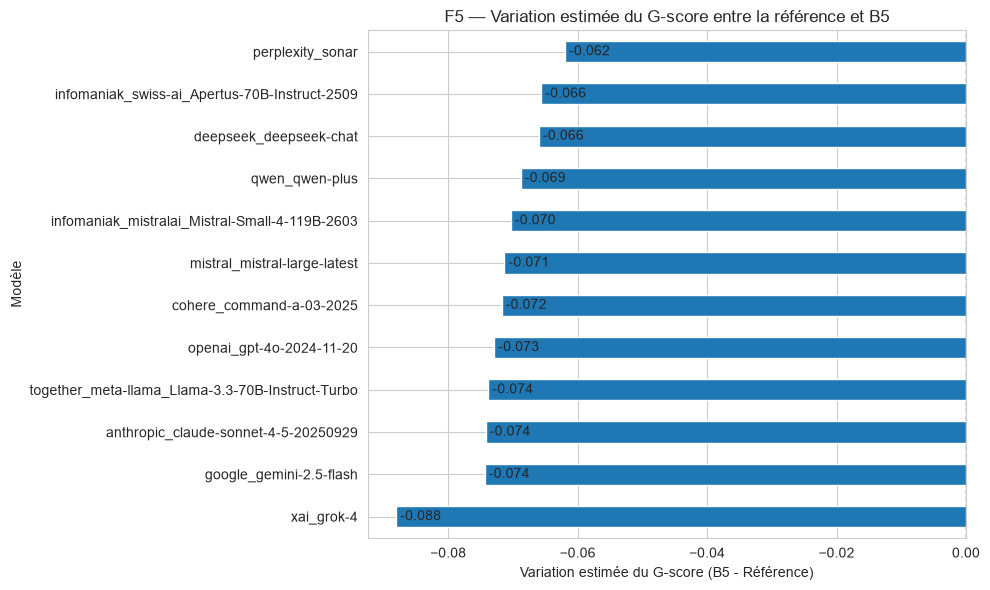

In [63]:
fig, ax = plt.subplots(figsize=(10, 6))

moyennes_pred['delta_B5'].plot(kind='barh',ax=ax)
ax.axvline(0, linestyle='--', linewidth=1)

for i, valeur in enumerate(moyennes_pred['delta_B5']):
    ax.text(valeur,i,f" {valeur:+.3f}",va='center')

ax.set_xlabel("Variation estimée du G-score (B5 - Référence)")
ax.set_ylabel("Modèle")
ax.set_title("F5 — Variation estimée du G-score entre la référence et B5")
plt.tight_layout()

plt.savefig('F5_variation_reference_B5_par_modele.png',dpi=150,bbox_inches='tight')
plt.show()

##### Interprétation

Tous les modèles présentent une baisse du G-score en B5. La baisse est la plus importante pour **Grok-4 (-0,088)** et la moins importante pour **Perplexity (-0,062)**, confirmant une rupture généralisée mais d'amplitude variable selon les modèles.

##### Synthèse du bloc F

Les modèles mixtes confirment une **baisse importante et généralisée du G-score en B5** par rapport à la période de référence (**-0,074 ; p < 0,001**). Cette baisse varie toutefois selon les modèles (**χ² = 361,729 ; p < 0,001**), avec une amplitude allant de **-0,088 pour Grok-4** à **-0,062 pour Perplexity**.

La rupture observée en B5 est donc **robuste, mais son intensité diffère selon les modèles**.

#### G. Persistance de la perturbation et campagnes de suivi

In [64]:
# G1 — Modèle mixte : Référence (B1-B4) vs B7 vs B8
# Question : le G-score revient-il vers son niveau de référence après B5 ?

df_g1 = df_canonique[df_canonique['baromètre'].isin(baros_reference + ['baromètre7', 'baromètre8'])].dropna(subset=['g_score']).copy()

df_g1['periode'] = np.where(df_g1['baromètre'].isin(baros_reference), 'Référence', df_g1['baromètre'].map({'baromètre7':'B7', 'baromètre8':'B8'}))
df_g1['periode'] = pd.Categorical(df_g1['periode'], categories=['Référence', 'B7', 'B8'])
df_g1['modèle'] = df_g1['modèle'].astype('category')

modele_mixte_g1 = mixedlm("g_score ~ C(modèle) * C(periode)", data=df_g1, groups=df_g1["prompt_id"])
resultat_mixte_g1 = modele_mixte_g1.fit(reml=True)

print(resultat_mixte_g1.summary())

                                          Mixed Linear Model Regression Results
Model:                                  MixedLM                       Dependent Variable:                       g_score   
No. Observations:                       28603                         Method:                                   REML      
No. Groups:                             4                             Scale:                                    0.0002    
Min. group size:                        7079                          Log-Likelihood:                           79785.9841
Max. group size:                        7192                          Converged:                                Yes       
Mean group size:                        7150.8                                                                            
--------------------------------------------------------------------------------------------------------------------------
                                                           

In [65]:
print(f"Variance réelle du prompt : {resultat_mixte_g1.cov_re.iloc[0,0]:.10f}")


Variance réelle du prompt : 0.0000025985


##### Interprétation

Le G-score revient globalement vers son niveau de référence en B7 et B8. Des
différences subsistent toutefois selon les modèles, notamment pour **Cohere**,
**Apertus** et **Perplexity**. Le retour apparaît donc largement effectif, mais
pas parfaitement homogène entre les modèles.

#### G2.Test global de l'évolution Référence → B7 → B8

In [66]:
#La prochaine étape est G2 — test global de l’interaction modèle × période pour B7/B8.
#C'est important parce que G1 nous montre quelques interactions significatives individuellement, mais on veut maintenant savoir si l'hétérogénéité entre modèles est globalement significative.

#On va comparer : modèle sans interaction : g_score ~ modèle + période vs modèle avec interaction : g_score ~ modèle * périod avec Référence / B7 / B8.

modele_g2_sans = mixedlm("g_score ~ C(modèle) + C(periode)", data=df_g1, groups=df_g1["prompt_id"]).fit(reml=False)
modele_g2_avec = mixedlm("g_score ~ C(modèle) * C(periode)", data=df_g1, groups=df_g1["prompt_id"]).fit(reml=False)

lr_stat_g2 = 2 * (modele_g2_avec.llf - modele_g2_sans.llf)
df_diff_g2 = modele_g2_avec.df_modelwc - modele_g2_sans.df_modelwc
p_g2 = stats.chi2.sf(lr_stat_g2, df_diff_g2)

print("G2 — Test global de l'interaction modèle × période")
print(f"Log-vraisemblance sans interaction : {modele_g2_sans.llf:.3f}")
print(f"Log-vraisemblance avec interaction : {modele_g2_avec.llf:.3f}")
print(f"Statistique du rapport de vraisemblance : {lr_stat_g2:.3f}")
print(f"Degrés de liberté : {df_diff_g2}")
print(f"p-value : {p_g2:.3e}")

G2 — Test global de l'interaction modèle × période
Log-vraisemblance sans interaction : 79607.420
Log-vraisemblance avec interaction : 80018.013
Statistique du rapport de vraisemblance : 821.187
Degrés de liberté : 22
p-value : 1.848e-159


##### Interprétation

Le test confirme une forte hétérogénéité entre les modèles. L'ajout de
l'interaction modèle × période améliore nettement l'ajustement du modèle :
la log-vraisemblance passe de **79 607,420** à **80 018,013**, avec
**χ² = 821,187**, **ddl = 22** et **p < 0,001**.

On rejette donc l'hypothèse d'une évolution identique des modèles entre
la période de référence, B7 et B8. Le retour du G-score après la rupture de B5
diffère donc selon les modèles, notamment pour **Cohere, Perplexity et Apertus**.

G3 permet ensuite de quantifier l'amplitude de ce retour pour chaque modèle.

#### G3. Amplitude du retour vers la référence par modèle

In [67]:
# But : quantifier, pour chaque modèle, l'écart entre le G-score estimé en B7/B8
# et celui de la période de référence B1-B4, afin de caractériser le retour après B5.

pred_g3 = df_g1[['modèle', 'periode', 'prompt_id']].drop_duplicates().copy()
pred_g3['g_score_pred'] = resultat_mixte_g1.predict(pred_g3)
moyennes_g3 = pred_g3.groupby(['modèle', 'periode'])['g_score_pred'].mean().unstack()
moyennes_g3['delta_B7'] = moyennes_g3['B7'] - moyennes_g3['Référence']
moyennes_g3['delta_B8'] = moyennes_g3['B8'] - moyennes_g3['Référence']
moyennes_g3 = moyennes_g3[['Référence', 'B7', 'B8', 'delta_B7', 'delta_B8']].sort_values('delta_B7')
print(" G3 — G-score estimé et amplitude du retour par modèle")
print(moyennes_g3.round(4).to_string())

 G3 — G-score estimé et amplitude du retour par modèle
periode                                           Référence      B7      B8  delta_B7  delta_B8
modèle                                                                                         
cohere_command-a-03-2025                             0.5981  0.5820  0.6000   -0.0161    0.0019
google_gemini-2.5-flash                              0.5999  0.5995  0.6000   -0.0004    0.0001
openai_gpt-4o-2024-11-20                             0.6000  0.6000  0.6000    0.0000    0.0000
xai_grok-4                                           0.5999  0.6000  0.5992    0.0001   -0.0007
deepseek_deepseek-chat                               0.5999  0.6000  0.6000    0.0001    0.0001
mistral_mistral-large-latest                         0.5997  0.5999  0.5997    0.0002    0.0000
anthropic_claude-sonnet-4-5-20250929                 0.5997  0.6000  0.6000    0.0003    0.0003
infomaniak_mistralai_Mistral-Small-4-119B-2603       0.5997  0.6000  0.6000    0.

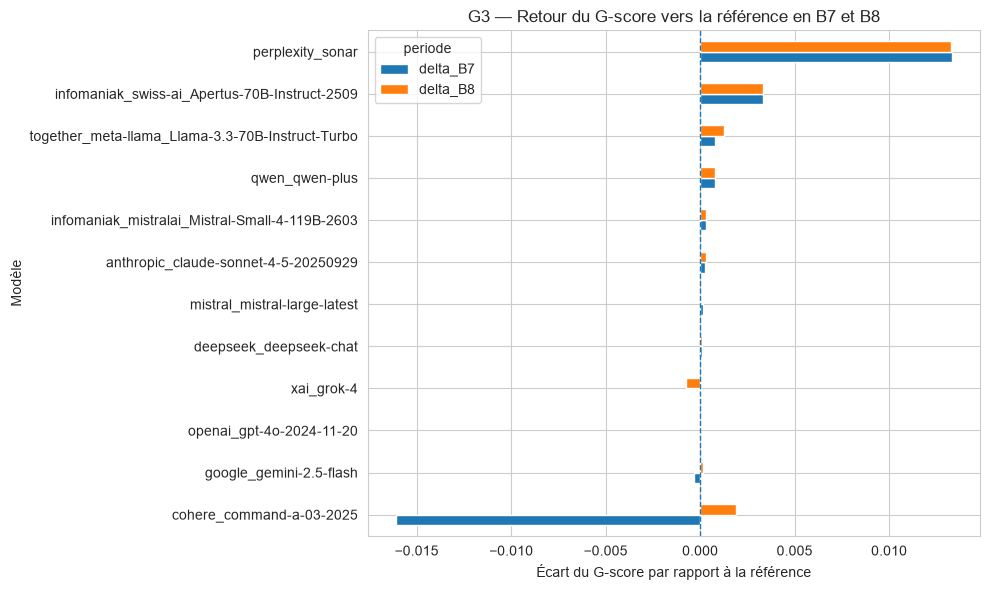

In [68]:
fig, ax = plt.subplots(figsize=(10, 6))

moyennes_g3[['delta_B7', 'delta_B8']].plot(kind='barh',ax=ax)
ax.axvline(0, linestyle='--', linewidth=1)

ax.set_xlabel("Écart du G-score par rapport à la référence")
ax.set_ylabel("Modèle")
ax.set_title("G3 — Retour du G-score vers la référence en B7 et B8")

plt.tight_layout()
plt.savefig("G3_retour_reference_B7_B8.png",dpi=150,bbox_inches='tight')
plt.show()

##### Interprétation

Le G-score revient très près du niveau de référence pour la majorité des modèles.
L'écart le plus marqué concerne **Cohere en B7 (-0,0161)**, mais il devient
quasi nul en B8 (**+0,0019**). À l'inverse, **Perplexity** reste légèrement
au-dessus de sa référence en B7 et B8 (**+0,0133**).

Globalement, le retour est donc largement effectif, avec quelques différences
selon les modèles.

#### G4.Synthèse de la trajectoire du G-score : Référence → B5 → B7 → B8

In [69]:
# G4 — Synthèse de la trajectoire du G-score : Référence → B5 → B7 → B8
# But : résumer, pour chaque modèle, l'évolution du G-score entre la période de référence,
# la rupture observée en B5 et les campagnes de suivi B7-B8, afin de caractériser
# la persistance ou la disparition de l'anomalie.

resume_g4 = df_canonique[df_canonique['baromètre'].isin(baros_reference + ['baromètre5', 'baromètre7', 'baromètre8'])
                         ].dropna(subset=['g_score']).copy()

resume_g4['periode'] = np.where(
    resume_g4['baromètre'].isin(baros_reference),
    'Référence',
    resume_g4['baromètre'].map({
        'baromètre5': 'B5',
        'baromètre7': 'B7',
        'baromètre8': 'B8'}))

moyennes_g4 = (resume_g4.groupby(['modèle', 'periode'])['g_score'].mean().unstack())
ordre = ['Référence', 'B5', 'B7', 'B8']
moyennes_g4 = moyennes_g4[ordre]

print(" G4 — Trajectoire du G-score")
print(moyennes_g4.round(4).to_string())

 G4 — Trajectoire du G-score
periode                                           Référence      B5      B7      B8
modèle                                                                             
anthropic_claude-sonnet-4-5-20250929                 0.5997  0.5255  0.6000  0.6000
cohere_command-a-03-2025                             0.5981  0.5263  0.5820  0.6000
deepseek_deepseek-chat                               0.5999  0.5339  0.6000  0.6000
google_gemini-2.5-flash                              0.5998  0.5255  0.5995  0.6000
infomaniak_mistralai_Mistral-Small-4-119B-2603       0.5997  0.5293  0.6000  0.6000
infomaniak_swiss-ai_Apertus-70B-Instruct-2509        0.5967  0.5310  0.6000  0.6000
mistral_mistral-large-latest                         0.5997  0.5284  0.5998  0.5997
openai_gpt-4o-2024-11-20                             0.6000  0.5271  0.6000  0.6000
perplexity_sonar                                     0.5867  0.5247  0.6000  0.6000
qwen_qwen-plus                                 

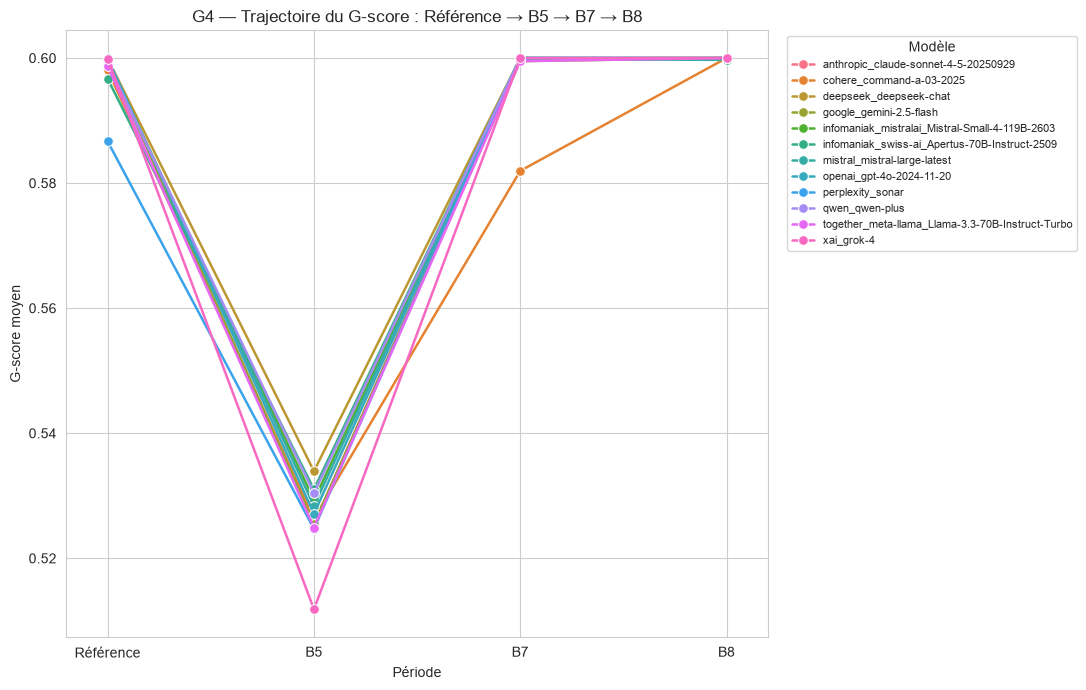

In [70]:

# G4 — Trajectoire statique : Référence → B5 → B7 → B8
# Version statique (matplotlib/seaborn), destinée au rapport PDF/LaTeX


df_plot_g4 = moyennes_g4.reset_index().melt(
    id_vars='modèle',
    value_vars=['Référence', 'B5', 'B7', 'B8'],
    var_name='periode',
    value_name='g_score'
)

ordre_periodes = ['Référence', 'B5', 'B7', 'B8']

fig, ax = plt.subplots(figsize=(11, 7))

sns.lineplot(
    data=df_plot_g4,
    x='periode',
    y='g_score',
    hue='modèle',
    marker='o',
    markersize=7,
    linewidth=1.8,
    ax=ax
)

ax.set_xlim(-0.2, 3.2)
ax.set_xticks(range(len(ordre_periodes)))
ax.set_xticklabels(ordre_periodes)
ax.set_xlabel("Période")
ax.set_ylabel("G-score moyen")
ax.set_title("G4 — Trajectoire du G-score : Référence → B5 → B7 → B8")
ax.legend(title="Modèle", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('G4_trajectoire_statique.png', dpi=200, bbox_inches='tight')
plt.show()

KeyError: 'Modèle'

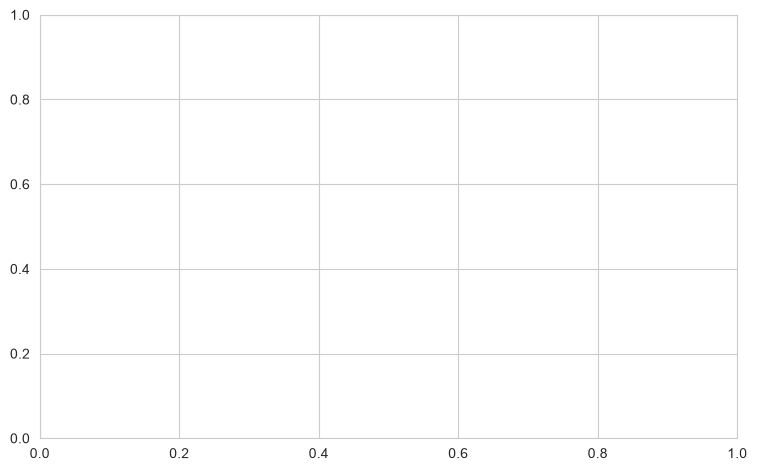

In [71]:
# G4 — Trajectoire globale du G-score (version à metrre dans le rapport )

ordre_periodes = ["Référence", "B5", "B7", "B8"]

# Moyenne globale par période
moyenne_globale = (
    df_plot_g4
    .groupby("periode", observed=True)["g_score"]
    .mean()
    .reindex(ordre_periodes)
)

fig, ax = plt.subplots(figsize=(9, 5.5))

# Courbes individuelles en arrière-plan
for modele, sous_df in df_plot_g4.groupby("Modèle"):

    valeurs = (
        sous_df
        .set_index("periode")["g_score"]
        .reindex(ordre_periodes)
    )

    ax.plot(
        range(4),
        valeurs.values,
        linewidth=1,
        alpha=0.25,
        marker="o",
        markersize=3
    )

# Trajectoire moyenne
ax.plot(
    range(4),
    moyenne_globale.values,
    marker="o",
    linewidth=3,
    markersize=7,
    label="Moyenne des modèles"
)

# Ligne verticale au niveau de B5
ax.axvline(
    x=1,
    linestyle="--",
    linewidth=1
)

# Valeurs de la trajectoire moyenne
for i, valeur in enumerate(moyenne_globale.values):
    ax.text(
        i,
        valeur + 0.004,
        f"{valeur:.4f}",
        ha="center",
        fontsize=9
    )

ax.set_xticks(range(4))
ax.set_xticklabels(ordre_periodes)

ax.set_xlabel("Période")
ax.set_ylabel("G-score moyen")

ax.set_title(
    "G4 — Trajectoire du G-score : Référence → B5 → B7 → B8"
)

ax.set_ylim(0.50, 0.605)

ax.legend()

ax.grid(
    axis="y",
    linestyle=":",
    alpha=0.4
)

plt.tight_layout()

plt.savefig(
    "G4_trajectoire_statique.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

##### Synthèse G4

La trajectoire montre une baisse nette du G-score en B5, suivie d'un retour
vers le niveau de référence en B7 et B8 pour la majorité des modèles.
La perturbation apparaît ainsi principalement **transitoire**, avec quelques
différences de trajectoire selon les modèles.



#### H. Facteurs opérationnels et robustesse

In [ ]:
# H1 — Relation entre le G-score et la latence
#
# But : déterminer si les variations du G-score sont associées aux variations de la latence d'exécution.
#
# Cette analyse vise surotut à évaluer si la latence constitue une
# condition d'exécution susceptible d'influencer le comportement observé du G-score
# !!L'analyse est exploratoire et ne permet pas, à elle seule,
# d'établir une relation causale entre latence et G-score.
latence_par_baro = df_canonique.groupby(['baromètre', 'modèle'])['latency_ms'].mean().reset_index()

##### H1.1 — Corrélation globale

Comme les distributions ne sont pas forcément normales et que nous avons déjà utilisé Spearman ailleurs, je partirais sur Spearman.

In [ ]:
# H1.1 — Corrélation de Spearman entre G-score et latence

df_h1 = df_canonique[['g_score', 'latency_ms']].dropna().copy()

rho_latence, p_latence = stats.spearmanr(df_h1['g_score'],df_h1['latency_ms'])

print("H1.1 — G-score vs latence")
print(f"Nombre d'observations : {len(df_h1)}")
print(f"Corrélation de Spearman : rho = {rho_latence:.4f}")
print(f"p-value : {p_latence:.4e}")

H1.1 — G-score vs latence
Nombre d'observations : 33401
Corrélation de Spearman : rho = 0.5662
p-value : 0.0000e+00


##### H1.2 - Faire le même calcul hors B5

In [ ]:
# H1.2 — Sensibilité de la relation à la campagne B5

for groupe, donnees in {
    'Toutes campagnes': df_canonique,
    'Référence B1-B4': df_canonique[
        df_canonique['baromètre'].isin(baros_reference)
    ],
    'B5': df_canonique[
        df_canonique['baromètre'] == 'baromètre5'
    ]
}.items():

    donnees = donnees[['g_score', 'latency_ms']].dropna()

    rho, p = stats.spearmanr(donnees['g_score'], donnees['latency_ms'])

    print(f"\n {groupe} ")
    print(f"n = {len(donnees)}")
    print(f"Spearman rho = {rho:.4f}")
    print(f"p-value = {p:.4e}")


 Toutes campagnes 
n = 33401
Spearman rho = 0.5662
p-value = 0.0000e+00

 Référence B1-B4 
n = 19112
Spearman rho = -0.0011
p-value = 8.7535e-01

 B5 
n = 4798
Spearman rho = -0.0169
p-value = 2.4183e-01


##### H1.3 — Relation entre G-score et latence

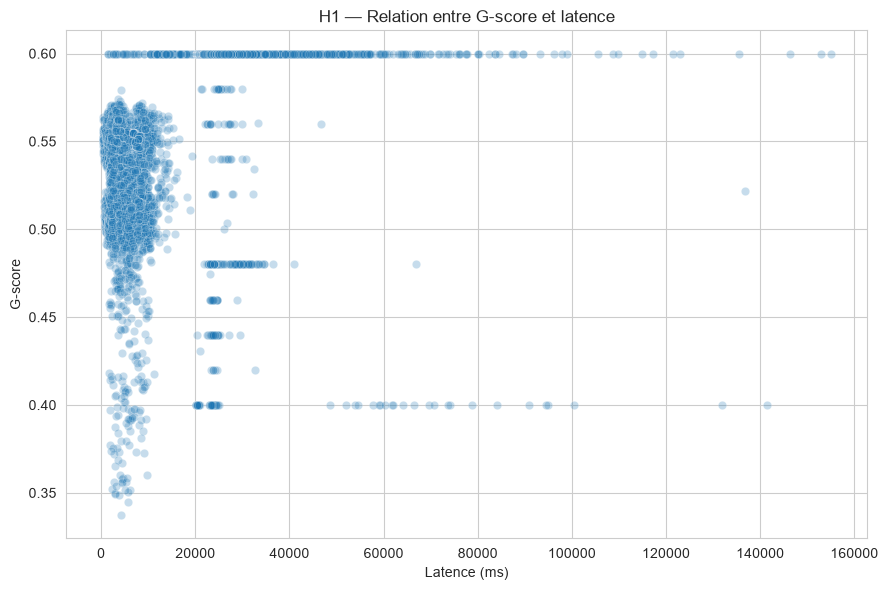

In [ ]:
plt.figure(figsize=(9, 6))

sns.scatterplot(data=df_h1, x='latency_ms', y='g_score', alpha=0.25)
plt.xlabel("Latence (ms)")
plt.ylabel("G-score")
plt.title("H1 — Relation entre G-score et latence")

plt.tight_layout()
plt.savefig('H1_relation_g_score_latence.png',dpi=150,bbox_inches='tight')
plt.show()

L'analyse de sensibilité à la latence met en évidence une corrélation de Spearman positive sur l'ensemble des observations (ρ = 0,5662 ; p < 0,001). Cependant, cette association disparaît lorsque les périodes sont analysées séparément : elle est quasi nulle sur la période de référence B1–B4 (ρ = −0,0011 ; p = 0,875) ainsi que sur B5 (ρ = −0,0169 ; p = 0,242). La corrélation globale ne semble donc pas traduire une relation intrinsèque entre la latence et le G-score, mais plutôt une différence de régime entre les campagnes. Ces résultats ne permettent pas de conclure à un effet de la latence sur le G-score.

#### H2. Relation entre le G-score et le nombre de tokens

##### H2.1 — Corrélation de Spearman entre G-score et nombre de tokens

In [73]:
# But du bloc généralement : déterminer si les variations du G-score sont associées
# au volume de tokens produit lors de l'exécution.
#
# L'analyse est réalisée globalement puis séparément sur la
# période de référence (B1-B4) et sur B5 afin de distinguer
# une éventuelle association générale d'un effet lié au changement
# de régime observé en B5.

for groupe, donnees in {'Toutes campagnes': df_canonique,'Référence B1-B4': df_canonique[df_canonique['baromètre'].isin(baros_reference)],
                        'B5': df_canonique[df_canonique['baromètre'] == 'baromètre5']}.items():

    donnees = donnees[
        ['g_score', 'token_count']].dropna()

    rho, p = stats.spearmanr(donnees['g_score'], donnees['token_count'])

    print(f"{groupe}")
    print(f"n = {len(donnees)}")
    print(f"Spearman rho = {rho:.4f}")
    print(f"p-value = {p:.4e}")

Toutes campagnes
n = 33401
Spearman rho = -0.0302
p-value = 3.4548e-08
Référence B1-B4
n = 19112
Spearman rho = -0.0362
p-value = 5.6874e-07
B5
n = 4798
Spearman rho = -0.0226
p-value = 1.1675e-01


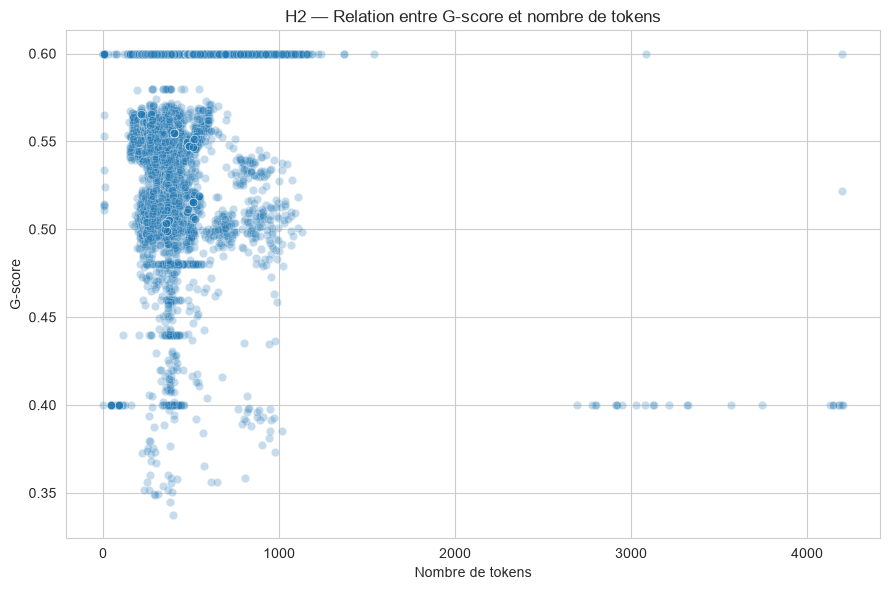

In [74]:
# visuualisation de la relation entre G-score et nombre de tokens 
df_h2 = df_canonique[
    ['g_score', 'token_count']
].dropna().copy()

plt.figure(figsize=(9, 6))

sns.scatterplot(data=df_h2,x='token_count',y='g_score',alpha=0.25)

plt.xlabel("Nombre de tokens")
plt.ylabel("G-score")
plt.title("H2 — Relation entre G-score et nombre de tokens")
plt.tight_layout()
plt.savefig('H2_relation_g_score_tokens.png',dpi=150,bbox_inches='tight')
plt.show()

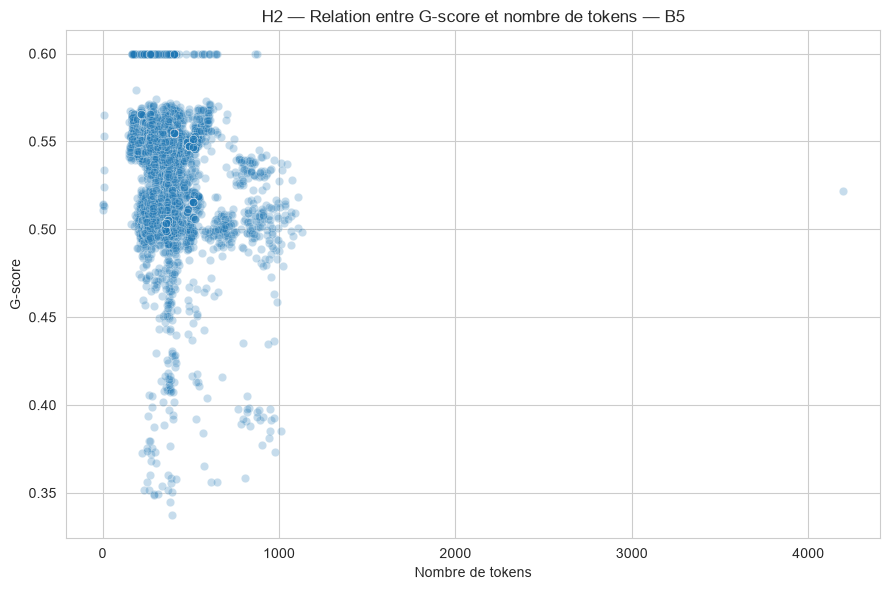

In [75]:
df_h2_b5 = df_canonique[
    df_canonique['baromètre'] == 'baromètre5'
][['g_score', 'token_count']].dropna().copy()

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_h2_b5,
    x='token_count',
    y='g_score',
    alpha=0.25
)

plt.xlabel("Nombre de tokens")
plt.ylabel("G-score")
plt.title("H2 — Relation entre G-score et nombre de tokens — B5")

plt.tight_layout()
plt.savefig(
    'H2_relation_g_score_tokens_B5.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

L'analyse de la relation entre le nombre de tokens et le G-score ne met pas en évidence d'association substantielle. Sur l'ensemble des campagnes, la corrélation de Spearman est très faible (ρ = −0,0302 ; p < 0,001). Elle reste de très faible amplitude sur la période de référence B1-B4 (ρ = −0,0362 ; p < 0,001) et devient non significative en B5 (ρ = −0,0226 ; p = 0,117). Malgré la significativité statistique observée sur B1-B4, l'amplitude des associations est suffisamment faible pour ne pas suggérer de relation importante entre le volume de tokens et le G-score. Ces résultats ne fournissent donc pas d'élément en faveur d'un effet substantiel du nombre de tokens sur le score G.

####  H3. Erreurs et conditions d'exécution

In [76]:
# But : caractériser la fréquence et la nature des erreurs
# selon les campagnes, afin de déterminer si B5 présente
# un profil opérationnel atypique.
#
# La présence d'une erreur est considérée comme un indicateur
# opérationnel. Cette analyse permet de documenter le contexte
# d'exécution, sans établir de relation causale avec le G-score.

df_h3 = df_canonique[['baromètre', 'modèle', 'error', 'g_score']].copy()

df_h3['erreur'] = df_h3['error'].notna()

resume_erreurs = (df_h3.groupby('baromètre').agg(observations=('erreur', 'size'),erreurs=('erreur', 'sum')))
resume_erreurs['taux_erreur'] = (100 * resume_erreurs['erreurs'] /resume_erreurs['observations'])
print(" H3.1 — Erreurs par baromètre ")
print(resume_erreurs.round(3))

 H3.1 — Erreurs par baromètre 
            observations  erreurs  taux_erreur
baromètre                                     
baromètre1          4800       25        0.521
baromètre2          4800       20        0.417
baromètre3          4800        1        0.021
baromètre4          4800       42        0.875
baromètre5          4800        2        0.042
baromètre7          4800        1        0.021
baromètre8          4800      108        2.250


In [77]:
print("H3.2 — Nature des erreurs")
print(df_h3.loc[df_h3['erreur'], 'error'].value_counts())

H3.2 — Nature des erreurs
error
The /stream endpoint returned no LLM response text.                                                185
Unable to read data from the transport connection: The connection was closed.                        9
The remote server returned an error: (502) Bad Gateway.                                              3
Stream failed after 5 attempts. Last error: The /stream endpoint returned no LLM response text.      2
Name: count, dtype: int64


##### Interprétation

L'analyse des erreurs d'exécution ne met pas en évidence de surreprésentation des erreurs lors de la campagne B5. Sur 4 800 observations, B5 présente seulement 2 erreurs, soit un taux de 0,042 %. À titre de comparaison, les taux observés sont de 0,521 % en B1, 0,417 % en B2, 0,021 % en B3, 0,875 % en B4, 0,021 % en B7 et 2,250 % en B8.

Ainsi, contrairement à ce qui pourrait être attendu au regard du contexte opérationnel rapporté pour B5, la variable d'erreur disponible dans les données ne montre pas d'augmentation particulière des échecs d'exécution lors de cette campagne. B5 ne peut donc pas être caractérisée comme atypique sur la seule base de ce taux d'erreur.

Les erreurs observées sont principalement liées à l'absence de texte retourné par le endpoint /stream (185 occurrences sur 199 erreurs), les autres incidents correspondant à des fermetures de connexion, des erreurs 502 ou des échecs après plusieurs tentatives.

Ces résultats doivent toutefois être interprétés avec prudence : l'absence d'un taux d'erreur élevé dans la variable disponible ne permet pas d'exclure d'autres problèmes opérationnels, notamment ceux liés aux relances, au routing, aux versions ou à la consolidation du backend. Ils constituent uniquement un indicateur des erreurs effectivement enregistrées dans les données analysées.

#### H4.Valeurs atypiques du G-score et analyse de robustesse

##### H4.1 Détection des valeurs atypiques

In [78]:
# But : identifier les observations présentant des valeurs
# atypiques du G-score et évaluer leur influence potentielle
# sur les résultats de l'étude.
#
# Les valeurs atypiques ne sont pas supprimées automatiquement.
# Elles sont d'abord identifiées afin de vérifier si elles
# correspondent à des observations particulières ou si elles
# peuvent influencer les conclusions principales.

df_h4 = df_canonique[['g_score', 'baromètre', 'modèle', 'prompt_id'] ].dropna(subset=['g_score']).copy()

Q1 = df_h4['g_score'].quantile(0.25)
Q3 = df_h4['g_score'].quantile(0.75)

IQR = Q3 - Q1

borne_inf = Q1 - 1.5 * IQR
borne_sup = Q3 + 1.5 * IQR

df_h4['atypique'] = ((df_h4['g_score'] < borne_inf) |(df_h4['g_score'] > borne_sup))

print("H4.1 — Valeurs atypiques du G-score")
print(f"Q1 : {Q1:.4f}")
print(f"Q3 : {Q3:.4f}")
print(f"IQR : {IQR:.4f}")
print(f"Borne inférieure : {borne_inf:.4f}")
print(f"Borne supérieure : {borne_sup:.4f}")
print(f"Nombre de valeurs atypiques : {df_h4['atypique'].sum()}")
print(f"Proportion : {100 * df_h4['atypique'].mean():.2f} %")

H4.1 — Valeurs atypiques du G-score
Q1 : 0.6000
Q3 : 0.6000
IQR : 0.0000
Borne inférieure : 0.6000
Borne supérieure : 0.6000
Nombre de valeurs atypiques : 4965
Proportion : 14.86 %


##### H4.2 - Répartition des valeurs atypiques par baromètre

In [79]:
atypiques_par_baro = (df_h4[df_h4['atypique']].groupby('baromètre').size().rename('n_atypiques'))
print("H4.2 — Valeurs atypiques par baromètre")
print(atypiques_par_baro)

H4.2 — Valeurs atypiques par baromètre
baromètre
baromètre1      41
baromètre2      86
baromètre3      70
baromètre4      63
baromètre5    4653
baromètre7      44
baromètre8       8
Name: n_atypiques, dtype: int64


##### H4.3 — Répartition des valeurs atypiques par modèle

In [80]:
atypiques_par_modele = (df_h4[df_h4['atypique']].groupby('modèle').size().rename('n_atypiques').sort_values(ascending=False))
print("H4.3 — Valeurs atypiques par modèle")
print(atypiques_par_modele)

H4.3 — Valeurs atypiques par modèle
modèle
perplexity_sonar                                    532
infomaniak_swiss-ai_Apertus-70B-Instruct-2509       441
cohere_command-a-03-2025                            439
together_meta-llama_Llama-3.3-70B-Instruct-Turbo    413
mistral_mistral-large-latest                        399
qwen_qwen-plus                                      398
infomaniak_mistralai_Mistral-Small-4-119B-2603      396
anthropic_claude-sonnet-4-5-20250929                392
google_gemini-2.5-flash                             390
deepseek_deepseek-chat                              389
openai_gpt-4o-2024-11-20                            388
xai_grok-4                                          388
Name: n_atypiques, dtype: int64


##### H4.4 — Analyse de sensibilité aux valeurs atypiques


In [81]:
# But : vérifier si les conclusions concernant la rupture du G-score
# entre la période de référence (B1-B4) et B5 sont robustes à
# l'exclusion temporaire des observations identifiées comme atypiques
# par la méthode IQR dans le bloc 0.
#
# Les observations atypiques ne sont pas supprimées du jeu de données
# principal. L'analyse est réalisée uniquement à titre de sensibilité.
#
# Il faut faire attention : compte tenu de la forte concentration du G-score autour
# de 0,6000, les observations identifiées par l'IQR peuvent refléter
# un changement de régime, notamment en B5, plutôt que des erreurs
# individuelles.



# H4.4 — Analyse de sensibilité aux valeurs atypiques
# But : comparer les résultats avec et sans les observations atypiques.

df_sens = df_h4[~df_h4['atypique']].copy()

df_h4['periode'] = np.where(df_h4['baromètre'].isin(baros_reference),'Référence',df_h4['baromètre'].map({'baromètre5': 'B5'}))

df_sens['periode'] = np.where(df_sens['baromètre'].isin(baros_reference),'Référence',df_sens['baromètre'].map({'baromètre5': 'B5'}))

resume_sens = df_h4.groupby('periode')['g_score'].mean().to_frame('Avec atypiques')
resume_sens['Sans atypiques'] = df_sens.groupby('periode')['g_score'].mean()
resume_sens['Variation'] = resume_sens['Sans atypiques'] - resume_sens['Avec atypiques']

print("---H4.4 — Analyse de sensibilité aux valeurs atypiques---")
print(f"Observations initiales : {len(df_h4)}")
print(f"Observations conservées : {len(df_sens)}")
print(f"Observations exclues : {df_h4['atypique'].sum()}")
print("\n --- Comparaison avec / sans valeurs atypiques----")
print(resume_sens.round(4))

---H4.4 — Analyse de sensibilité aux valeurs atypiques---
Observations initiales : 33401
Observations conservées : 28436
Observations exclues : 4965

 --- Comparaison avec / sans valeurs atypiques----
           Avec atypiques  Sans atypiques  Variation
periode                                             
B5                 0.5266             0.6     0.0734
Référence          0.5982             0.6     0.0018


##### Interprétation

L'analyse de sensibilité exclut **4 965 observations atypiques sur 33 401
(14,9 %)**. Leur exclusion modifie très peu le G-score de référence
(**+0,0018**), mais ramène fortement le G-score de B5 de **0,5266 à 0,6000**
(**+0,0734**).

Les observations identifiées comme atypiques sont donc principalement
associées à la rupture observée en B5. Elles semblent refléter un **changement
de régime** plutôt que de simples valeurs aberrantes isolées. Les observations
B5 ne doivent donc pas être considérées automatiquement comme des erreurs.

#### I. Synthèse finale, limites

#### I1. Synthèse des résultats principaux

L'analyse met en évidence une **baisse nette du G-score en B5** par rapport à la période de référence B1-B4. Cette rupture est statistiquement significative et son amplitude varie selon les modèles, comme le montre le test global de l'interaction modèle × période.

Les campagnes B7 et B8 montrent ensuite un **retour du G-score vers son niveau de référence pour la majorité des modèles**. L'ampleur de ce retour reste toutefois légèrement différente selon les modèles.

Les analyses complémentaires portant sur la latence, le nombre de tokens, les erreurs d'exécution et les valeurs atypiques permettent de mieux caractériser cette rupture. L'analyse de sensibilité montre notamment que les observations identifiées comme atypiques sont fortement associées au changement de régime observé en B5.

Dans l'ensemble, les résultats indiquent donc une **perturbation principalement transitoire du G-score en B5**, suivie d'un retour vers les niveaux observés avant la rupture.

#### I2. Limites et précautions d'interprétation

Les résultats doivent être interprétés en tenant compte de plusieurs limites.

- Le nombre de **prompts est limité à 4**, ce qui réduit la portée de la généralisation des résultats.
- Les observations sont répétées pour un même prompt et ne peuvent donc pas être considérées comme totalement indépendantes ; cette structure a été prise en compte dans les modèles mixtes.
- L'analyse des valeurs atypiques montre que la méthode IQR identifie fortement les observations de B5, ce qui semble davantage refléter un **changement de régime** qu'une série de valeurs aberrantes indépendantes.
- Le G-score doit être interprété comme un **signal de stabilité ou de comportement**, et non comme une mesure directe de la factualité ou de la qualité des réponses.
- Enfin, certaines analyses sont de nature exploratoire et doivent être considérées comme des éléments de caractérisation plutôt que comme des preuves définitives.

Ces limites n'annulent pas les résultats observés, mais invitent à privilégier une **interprétation comparative et multi-signal** des variations du G-score.